# First Implementation 


>>There is the pipeline
**camera.py**: builds the intrinsics for each pyramid level
**frameData.py**: stores image, derivatives, inverse depth, and pose
**pose_estimator_gauss_newton.py**: optimizes the pose
**common.py**: bilinear interpolation
**dataset/desktop_dataset/images**: input images
**Depth-Anything**: computes depth maps on the fly from the images


### Import


In [1]:
from pathlib import Path
import copy
import hashlib
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torchvision.transforms import Compose

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent

PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))

import importlib.util
try:
    import camera
except ModuleNotFoundError:
    camera_path = SCRIPT_DIR / "camera.py"
    if camera_path.exists():
        spec = importlib.util.spec_from_file_location("camera", str(camera_path))
        camera = importlib.util.module_from_spec(spec)
        spec.loader.exec_module(camera)
        sys.modules["camera"] = camera
    else:
        raise
import common
import frameData
import pose_estimator_gauss_newton


In [2]:
plt.rcParams["figure.figsize"] = (8, 5)
np.set_printoptions(precision=6, suppress=True)

ROOT = Path.cwd()
if not (ROOT / "scripts" / "python_visual_odometry").exists() and (ROOT.parent / "scripts" / "python_visual_odometry").exists():
    ROOT = ROOT.parent
PROJECT_ROOT = ROOT
SCRIPT_DIR = PROJECT_ROOT / "scripts" / "python_visual_odometry"
DEPTH_ANYTHING_DIR = PROJECT_ROOT / "Depth-Anything"

if not DEPTH_ANYTHING_DIR.exists():
    raise FileNotFoundError(f"Depth-Anything not found: {DEPTH_ANYTHING_DIR}")

if str(DEPTH_ANYTHING_DIR) not in sys.path:
    sys.path.insert(0, str(DEPTH_ANYTHING_DIR))

from depth_anything.dpt import DepthAnything
from depth_anything.util.transform import NormalizeImage, PrepareForNet, Resize



C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:


DEPTH_ENCODER = "vitb"
DEPTH_MODEL_NAME = f"LiheYoung/depth_anything_{DEPTH_ENCODER}14"
DEPTH_CACHE_DIR = SCRIPT_DIR / "depth_anything_cache" / DEPTH_ENCODER
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEPTH_CACHE_DIR.mkdir(parents=True, exist_ok=True)


--------------

### Notebook utility functions




---
### Convert to frame, create a list of these frames

In [4]:
import convert_video_frame
VIDEO_PATH = PROJECT_ROOT / "dataset" / "real" / "real0.mp4"
FRAMES_OUTPUT_DIR = PROJECT_ROOT / "dataset" / "real" / "real0_frames_first30"
IMAGE_OUTPUT_DIR = PROJECT_ROOT / "image"
IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if FRAMES_OUTPUT_DIR.exists():
    for existing_file in FRAMES_OUTPUT_DIR.glob("*.png"):
        existing_file.unlink()
else:
    FRAMES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise ValueError(f"Impossible d'ouvrir la video : {VIDEO_PATH}")

fps = float(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
max_frames = 30
saved_idx = 0

print(f"Video source : {VIDEO_PATH}")
print(f"FPS : {fps}")
print(f"Nombre total de trames dans la video : {frame_count}")
print(f"Extraction des {max_frames} premieres frames vers : {FRAMES_OUTPUT_DIR}")

while saved_idx < max_frames:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frame_path = FRAMES_OUTPUT_DIR / f"frame_{saved_idx:05d}.png"
    if not convert_video_frame.save_frame(frame_path, gray_frame):
        cap.release()
        raise IOError(f"Echec de l'ecriture de l'image : {frame_path}")

    saved_idx += 1

cap.release()
print(f"{saved_idx} frames sauvegardees dans : {FRAMES_OUTPUT_DIR}")

if saved_idx < 3:
    raise ValueError("Il faut au moins 3 frames pour estimer les intrinseques.")


Video source : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0.mp4
FPS : 25.0
Nombre total de trames dans la video : 509
Extraction des 30 premieres frames vers : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30


30 frames sauvegardees dans : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30


In [5]:
dossier_fake = FRAMES_OUTPUT_DIR

In [6]:
fake_frame_paths = sorted(
    str(f.resolve())
    for f in dossier_fake.rglob("*.png")
    if f.is_file()
)

print(f"{len(fake_frame_paths)} fichiers trouves dans {dossier_fake}")

if len(fake_frame_paths) != 30:
    raise ValueError(f"Le dossier de travail doit contenir exactement 30 frames, obtenu: {len(fake_frame_paths)}")


30 fichiers trouves dans C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30


In [7]:

KEYFRAME_PATH = fake_frame_paths[0]
TARGET_PATH= fake_frame_paths[1]

print(KEYFRAME_PATH)
print(TARGET_PATH)

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00000.png
C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00001.png


Here we rewrite a few small helper functions to make the pipeline explicit:

- load a grayscale image from its path
- compute a depth map with Depth Anything
- convert depth -> inverse depth
- quickly display a 4x4 matrix

The depth is inferred directly from the corresponding image with the `vitb` encoder, and can optionally be cached in `depth_anything_cache/vitb` to avoid recomputing it every time.

The important conversion is:

$$
\rho = \frac{1}{d}
$$

where **d** is the depth and **rho** is the inverse depth expected by the solver.

In [8]:


#PERMET DE NORMALISER LE CHEMIN DE L'IMAGE, EN S'ASSURANT QU'IL EST ABSOLU ET QU'IL EXISTE
def normalize_image_path(path_like) -> Path:
    path = Path(path_like)
    if not path.is_absolute():
        path = (ROOT / path).resolve()
    if not path.exists():
        raise FileNotFoundError(f"Image not found: {path}")
    return path



#PERMET DE CONSTRUIRE LE CHEMIN DE CACHE POUR LA CARTE DE PROFONDEUR CORRESPONDANTE À UNE IMAGE, EN UTILISANT UN HASH DU CHEMIN DE L'IMAGE POUR ÉVITER LES CONFLITS
def build_depth_cache_path(image_path: Path) -> Path:
    safe_name = image_path.stem.replace(" ", "_")
    cache_key = hashlib.md5(str(image_path.resolve()).encode("utf-8")).hexdigest()[:8]
    cache_name = f"{safe_name}_{cache_key}_depth.npy"
    return DEPTH_CACHE_DIR / cache_name


#PERMET DE CHARGER UNE IMAGE EN NIVEAUX DE GRIS À PARTIR D'UN CHEMIN, EN UTILISANT OPENCV POUR LIRE LE FICHIER ET LE CONVERTIR EN UN TABLEAU NUMPY
def load_gray_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return image


def load_rgb_image(image_path) -> np.ndarray:
    path = normalize_image_path(image_path)
    buffer = np.fromfile(path, dtype=np.uint8)
    image_bgr = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def get_depth_anything_components():
    if not hasattr(get_depth_anything_components, "model"):
        previous_cwd = Path.cwd()
        try:
            os.chdir(DEPTH_ANYTHING_DIR)
            model = DepthAnything.from_pretrained(DEPTH_MODEL_NAME).to(DEVICE).eval()
        finally:
            os.chdir(previous_cwd)

        transform = Compose([
            Resize(
                width=518,
                height=518,
                resize_target=False,
                keep_aspect_ratio=True,
                ensure_multiple_of=14,
                resize_method="lower_bound",
                image_interpolation_method=cv2.INTER_CUBIC,
            ),
            NormalizeImage(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
            PrepareForNet(),
        ])
        get_depth_anything_components.model = model
        get_depth_anything_components.transform = transform

        total_params = sum(param.numel() for param in model.parameters())
        print(f"Depth Anything loaded on {DEVICE} ({total_params / 1e6:.2f}M parameters)")

    return get_depth_anything_components.model, get_depth_anything_components.transform


def load_depth_map(image_path, use_cache: bool = True, save_cache: bool = True) -> np.ndarray:
    path = normalize_image_path(image_path)
    cache_path = build_depth_cache_path(path)
    if use_cache and cache_path.exists():
        return np.load(cache_path).astype(np.float32)

    image = load_rgb_image(path).astype(np.float32) / 255.0
    h, w = image.shape[:2]

    model, transform = get_depth_anything_components()
    image = transform({"image": image})["image"]
    image = torch.from_numpy(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        depth = model(image)

    depth = F.interpolate(depth[None], (h, w), mode="bilinear", align_corners=False)[0, 0]
    depth = depth.cpu().numpy().astype(np.float32)

    if save_cache:
        np.save(cache_path, depth)

    return depth


def depth_to_invdepth(depth: np.ndarray):
    inv_depth = np.zeros_like(depth, dtype=np.float32)
    valid_mask = depth > 1e-6
    inv_depth[valid_mask] = 1.0 / depth[valid_mask]
    inv_depth_var = np.ones_like(depth, dtype=np.float32)
    inv_depth_var[~valid_mask] = 1e6
    return inv_depth, inv_depth_var, valid_mask


def show_pose_matrix(title: str, pose):
    matrix = pose.as_matrix()
    print(title)
    print(matrix)
    return matrix


### Extract keyframe

Here we load:

- the reference image specified in `KEYFRAME_PATH`
- the depth map inferred by **Depth Anything** for this image

This image provides the base 3D geometry.


In [9]:
keyframe_image_path = normalize_image_path(KEYFRAME_PATH)
keyframe_image = load_gray_image(keyframe_image_path)
keyframe_depth = load_depth_map(keyframe_image_path)
keyframe_inv_depth, keyframe_inv_depth_var, valid_mask = depth_to_invdepth(keyframe_depth)


In [10]:

print("keyframe_image_path =", keyframe_image_path)
print("keyframe_image shape =", keyframe_image.shape, "dtype =", keyframe_image.dtype)
print("keyframe_depth shape =", keyframe_depth.shape, "dtype =", keyframe_depth.dtype)
print("depth min/max =", float(keyframe_depth.min()), float(keyframe_depth.max()))
print("valid depth ratio =", float(valid_mask.mean()))


keyframe_image_path = C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00000.png
keyframe_image shape = (2160, 3840) dtype = uint8
keyframe_depth shape = (2160, 3840) dtype = float32
depth min/max = 0.0 30.52671241760254
valid depth ratio = 0.027936077353395063


Text(0.5, 1.0, 'Inverse depth')

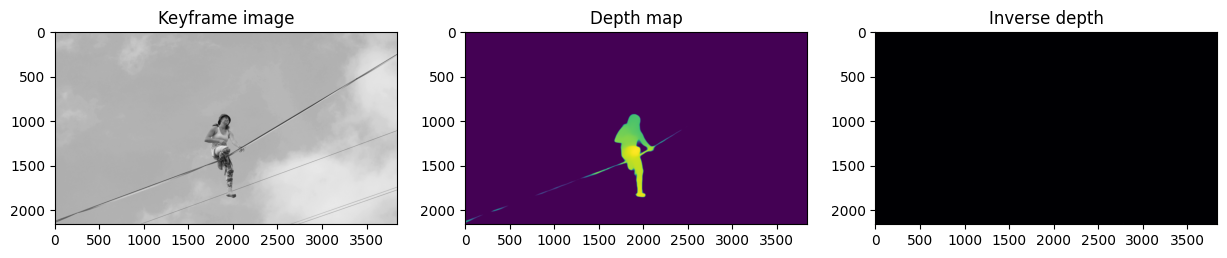

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))




axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title("Keyframe image")

axes[1].imshow(keyframe_depth, cmap="viridis")
axes[1].set_title("Depth map")


axes[2].imshow(keyframe_inv_depth, cmap="magma")
axes[2].set_title("Inverse depth")




### **Intrinsics estimated from real0.mp4**


Les intrinseques sont estimees automatiquement une seule fois a partir de 3 frames reparties sur les **30 premieres images** de `real0.mp4`.
Le resultat alimente ensuite **tout le notebook** et la boucle sequence complete.



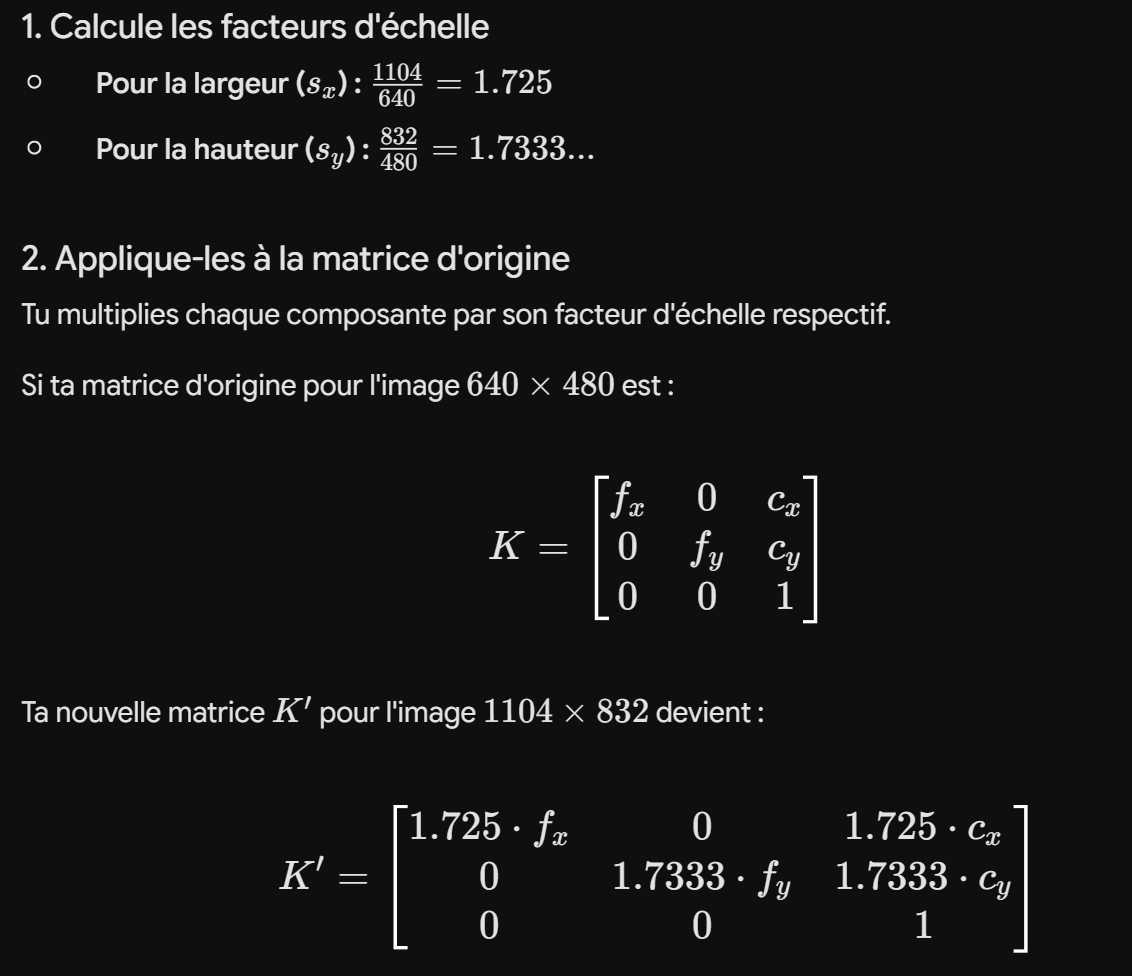

In [12]:

import base64
from IPython.display import HTML
with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
    with open(r"C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\capture.png","rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')
HTML(f'<div style="text-align:center;"><img src="data:image/png;base64,{b64}" width="900"/></div>')

In [13]:
# ==================================================
# Intrinseques estimees UNE FOIS au debut
# ==================================================
from estimate_intrinsics import estimate_camera_intrinsics_from_frames

loaded_height, loaded_width = keyframe_image.shape[:2]
frames_for_intrinsics = fake_frame_paths[:30]

candidate_index_sets = []
if len(frames_for_intrinsics) >= 30:
    candidate_index_sets.extend(
        [
            [0, 10, 20],
            [0, 14, 29],
            [5, 15, 25],
            [0, 1, 2],
        ]
    )

candidate_index_sets.append(np.linspace(0, len(frames_for_intrinsics) - 1, 3, dtype=int).tolist())

estimated_K = None
used_intrinsic_paths = None
last_error = None

for raw_indices in candidate_index_sets:
    candidate_indices = [int(min(max(index, 0), len(frames_for_intrinsics) - 1)) for index in raw_indices]
    if len(set(candidate_indices)) < 3:
        continue

    sample_paths = [normalize_image_path(frames_for_intrinsics[index]) for index in candidate_indices]
    sample_frames = [load_gray_image(path) for path in sample_paths]

    try:
        estimated_K = estimate_camera_intrinsics_from_frames(sample_frames)
        used_intrinsic_paths = sample_paths
        break
    except Exception as exc:
        print(f"Echec estimation intrinseques avec indices {candidate_indices}: {exc}")
        last_error = exc

if estimated_K is None:
    raise RuntimeError(f"Impossible d'estimer les intrinseques pour real0.mp4. Derniere erreur: {last_error}")

USER_WIDTH = loaded_width
USER_HEIGHT = loaded_height
USER_FX = float(estimated_K[0, 0])
USER_FY = float(estimated_K[1, 1])
USER_CX = float(estimated_K[0, 2])
USER_CY = float(estimated_K[1, 2])

intrinsics_user = {
    "width": USER_WIDTH,
    "height": USER_HEIGHT,
    "fx": USER_FX,
    "fy": USER_FY,
    "cx": USER_CX,
    "cy": USER_CY,
}

K_user = np.array(
    [
        [USER_FX, 0.0, USER_CX],
        [0.0, USER_FY, USER_CY],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    USER_WIDTH,
    USER_HEIGHT,
)

intrinsics_used_lvl0 = {
    "width": cam.width[0],
    "height": cam.height[0],
    "fx": cam.fx[0],
    "fy": cam.fy[0],
    "cx": cam.cx[0],
    "cy": cam.cy[0],
}

K_used_lvl0 = np.array(
    [
        [cam.fx[0], 0.0, cam.cx[0]],
        [0.0, cam.fy[0], cam.cy[0]],
        [0.0, 0.0, 1.0],
    ],
    dtype=np.float64,
)

print("Loaded keyframe size:")
print("  width  =", loaded_width)
print("  height =", loaded_height)
print()
print("Frames utilisees pour estimer les intrinseques:")
for path in used_intrinsic_paths:
    print(" ", path)
print()
print("Intrinseques estimees au debut du notebook:")
print(intrinsics_user)
print()
print("K_user =")
print(K_user)
print()
print("Internal working resolution used by the pipeline (level 0):")
print("  width  =", intrinsics_used_lvl0["width"])
print("  height =", intrinsics_used_lvl0["height"])
print()
print("K_used_lvl0 =")
print(K_used_lvl0)


Loaded keyframe size:
  width  = 3840
  height = 2160

Frames utilisees pour estimer les intrinseques:
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00000.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00010.png
  C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00020.png

Intrinseques estimees au debut du notebook:
{'width': 3840, 'height': 2160, 'fx': 1382.3999901855345, 'fy': 1382.3999901855345, 'cx': 1920.0, 'cy': 1080.0}

K_user =
[[1382.39999    0.      1920.     ]
 [   0.      1382.39999 1080.     ]
 [   0.         0.         1.     ]]

Internal working resolution used by the pipeline (level 0):
  width  = 640
  height = 480

K_used_lvl0 =
[[230.399998   0.       320.      ]
 [  0.       307.199998 240.      ]
 [  0.         0.         1.      ]]


In [14]:
scale_x = cam.width[0] / USER_WIDTH
scale_y = cam.height[0] / USER_HEIGHT

print("Check that the pipeline camera really comes from the USER intrinsics above:")
print("  scale_x =", scale_x)
print("  scale_y =", scale_y)
print()
print("  USER_FX -> cam.fx[0] :", USER_FX, "->", cam.fx[0])
print("  USER_FY -> cam.fy[0] :", USER_FY, "->", cam.fy[0])
print("  USER_CX -> cam.cx[0] :", USER_CX, "->", cam.cx[0])
print("  USER_CY -> cam.cy[0] :", USER_CY, "->", cam.cy[0])
print()
print("Expected level-0 values after internal resize:")
print("  expected fx =", USER_FX * scale_x)
print("  expected fy =", USER_FY * scale_y)
print("  expected cx =", USER_CX * scale_x)
print("  expected cy =", USER_CY * scale_y)

assert np.isclose(cam.fx[0], USER_FX * scale_x)
assert np.isclose(cam.fy[0], USER_FY * scale_y)
assert np.isclose(cam.cx[0], USER_CX * scale_x)
assert np.isclose(cam.cy[0], USER_CY * scale_y)

print()
print("Assertion passed: the notebook is using the intrinsics defined above.")


Check that the pipeline camera really comes from the USER intrinsics above:
  scale_x = 0.16666666666666666
  scale_y = 0.2222222222222222

  USER_FX -> cam.fx[0] : 1382.3999901855345 -> 230.39999836425574
  USER_FY -> cam.fy[0] : 1382.3999901855345 -> 307.19999781900765
  USER_CX -> cam.cx[0] : 1920.0 -> 320.0
  USER_CY -> cam.cy[0] : 1080.0 -> 240.0

Expected level-0 values after internal resize:
  expected fx = 230.39999836425574
  expected fy = 307.19999781900765
  expected cx = 320.0
  expected cy = 240.0

Assertion passed: the notebook is using the intrinsics defined above.


### Verification for every pyramid level

On affiche maintenant les intrinseques utilisees a **chaque niveau** de la pyramide, et on verifie qu elles correspondent bien a la regle automatique du code : division par `2**lvl` a partir du niveau 0.

In [15]:
intrinsics_per_level = []
base_fx = cam.fx[0]
base_fy = cam.fy[0]
base_cx = cam.cx[0]
base_cy = cam.cy[0]
base_width = cam.width[0]
base_height = cam.height[0]

print("Intrinsics used for each pyramid level:")
print()

for lvl in range(len(cam.fx)):
    scale = 2 ** lvl
    expected_fx = base_fx / scale
    expected_fy = base_fy / scale
    expected_cx = base_cx / scale
    expected_cy = base_cy / scale
    expected_width = int(base_width / scale)
    expected_height = int(base_height / scale)

    K_lvl = np.array([
        [cam.fx[lvl], 0.0, cam.cx[lvl]],
        [0.0, cam.fy[lvl], cam.cy[lvl]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    assert np.isclose(cam.fx[lvl], expected_fx)
    assert np.isclose(cam.fy[lvl], expected_fy)
    assert np.isclose(cam.cx[lvl], expected_cx)
    assert np.isclose(cam.cy[lvl], expected_cy)
    assert cam.width[lvl] == expected_width
    assert cam.height[lvl] == expected_height

    intrinsics_per_level.append({
        "level": lvl,
        "scale": scale,
        "width": cam.width[lvl],
        "height": cam.height[lvl],
        "fx": cam.fx[lvl],
        "fy": cam.fy[lvl],
        "cx": cam.cx[lvl],
        "cy": cam.cy[lvl],
        "K": K_lvl,
    })

    print(f"LEVEL {lvl}")
    print(f"  scale  = 1 / {scale}")
    print(f"  size   = {cam.width[lvl]} x {cam.height[lvl]}")
    print(f"  fx, fy = {cam.fx[lvl]:.6f}, {cam.fy[lvl]:.6f}")
    print(f"  cx, cy = {cam.cx[lvl]:.6f}, {cam.cy[lvl]:.6f}")
    print("  K =")
    print(K_lvl)
    print()

print("All assertions passed: each level uses the expected intrinsics.")


Intrinsics used for each pyramid level:

LEVEL 0
  scale  = 1 / 1
  size   = 640 x 480
  fx, fy = 230.399998, 307.199998
  cx, cy = 320.000000, 240.000000
  K =
[[230.399998   0.       320.      ]
 [  0.       307.199998 240.      ]
 [  0.         0.         1.      ]]

LEVEL 1
  scale  = 1 / 2
  size   = 320 x 240
  fx, fy = 115.199999, 153.599999
  cx, cy = 160.000000, 120.000000
  K =
[[115.199999   0.       160.      ]
 [  0.       153.599999 120.      ]
 [  0.         0.         1.      ]]

LEVEL 2
  scale  = 1 / 4
  size   = 160 x 120
  fx, fy = 57.600000, 76.799999
  cx, cy = 80.000000, 60.000000
  K =
[[57.6       0.       80.      ]
 [ 0.       76.799999 60.      ]
 [ 0.        0.        1.      ]]

LEVEL 3
  scale  = 1 / 8
  size   = 80 x 60
  fx, fy = 28.800000, 38.400000
  cx, cy = 40.000000, 30.000000
  K =
[[28.8  0.  40. ]
 [ 0.  38.4 30. ]
 [ 0.   0.   1. ]]

LEVEL 4
  scale  = 1 / 16
  size   = 40 x 30
  fx, fy = 14.400000, 19.200000
  cx, cy = 20.000000, 15.000000
  K

In [16]:

keyframe = frameData.frameData()
keyframe.setImage(keyframe_image)
keyframe.setInvDepth(keyframe_inv_depth, keyframe_inv_depth_var)

print("Pyramid levels =", len(keyframe.image))
for lvl in range(len(keyframe.image)):
    print(
        f"level {lvl}: image={keyframe.image[lvl].shape}, "
        f"invDepth={keyframe.invDepth[lvl].shape}, "
        f"grad={keyframe.imageDerivative[lvl].shape}"
    )


Pyramid levels = 5
level 0: image=(480, 640), invDepth=(480, 640), grad=(480, 640, 2)
level 1: image=(240, 320), invDepth=(240, 320), grad=(240, 320, 2)
level 2: image=(120, 160), invDepth=(120, 160), grad=(120, 160, 2)
level 3: image=(60, 80), invDepth=(60, 80), grad=(60, 80, 2)
level 4: image=(30, 40), invDepth=(30, 40), grad=(30, 40, 2)


### Extract the the current image




Now we take a second image, specified in `TARGET_PATH`.

This is the image whose relative pose with respect to the keyframe we want to estimate.
At first, its pose is the identity, and then the solver updates it.

In [17]:
current_image_path = normalize_image_path(TARGET_PATH)
current_image = load_gray_image(current_image_path)

current_frame = frameData.frameData()
current_frame.setImage(current_image)



### Recap

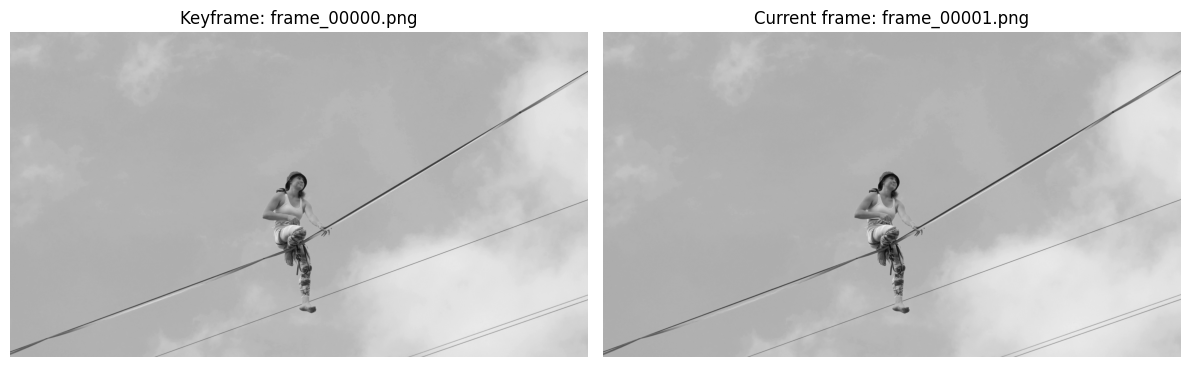

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(keyframe_image, cmap="gray")
axes[0].set_title(f"Keyframe: {keyframe_image_path.name}")


axes[1].imshow(current_image, cmap="gray")
axes[1].set_title(f"Current frame: {current_image_path.name}")


for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()


---
### **Initial pose and optimization updates**

Dans la cellule suivante, `pose_solver` est cree avec `cam`.
Donc les intrinseques utilisees pour l'estimation de pose sont bien celles affichees juste au-dessus.


In [19]:
pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(cam, show_debug=False)

print("Proof before optimization:")
print("  pose_solver.camera is cam ->", pose_solver.camera is cam)
print("  pose_solver.camera.fx[0] =", pose_solver.camera.fx[0])
print("  pose_solver.camera.fy[0] =", pose_solver.camera.fy[0])
print("  pose_solver.camera.cx[0] =", pose_solver.camera.cx[0])
print("  pose_solver.camera.cy[0] =", pose_solver.camera.cy[0])
print()
print("Reference level-0 intrinsics that should match:")
print(intrinsics_used_lvl0)
print()

initial_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
initial_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
initial_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Initial photometric errors before optimization:")
print("  level 4 =", initial_error_lvl4)
print("  level 3 =", initial_error_lvl3)
print("  level 2 =", initial_error_lvl2)


Proof before optimization:
  pose_solver.camera is cam -> True
  pose_solver.camera.fx[0] = 230.39999836425574
  pose_solver.camera.fy[0] = 307.19999781900765
  pose_solver.camera.cx[0] = 320.0
  pose_solver.camera.cy[0] = 240.0

Reference level-0 intrinsics that should match:
{'width': 640, 'height': 480, 'fx': 230.39999836425574, 'fy': 307.19999781900765, 'cx': 320.0, 'cy': 240.0}

Initial photometric errors before optimization:
  level 4 = 259.7027027027024
  level 3 = 250.13076923076872
  level 2 = 284.27976190476113


**optPose(...)** performs several updates:

- it computes an error
- it locally linearizes the problem
- it computes a pose increment
- it accepts or rejects this update depending on the error improvement

At the end, **current_frame.pose** contains the estimated extrinsic matrix of the current frame relative to the keyframe.


In [20]:
pose_solver.optPose(current_frame, keyframe)

final_error_lvl4, _ = pose_solver.computeError(current_frame, keyframe, lvl=4)
final_error_lvl3, _ = pose_solver.computeError(current_frame, keyframe, lvl=3)
final_error_lvl2, _ = pose_solver.computeError(current_frame, keyframe, lvl=2)

print("Final photometric errors after optimization:")
print("  level 4 =", final_error_lvl4)
print("  level 3 =", final_error_lvl3)
print("  level 2 =", final_error_lvl2)


lvl:  4  initial error:  259.7027027027024
 error improvement too small, level converged! it:  5  error:  211.19905588966483  lambda:  14073748835532.8
lvl:  3  initial error:  1222.4776788473305


 error improvement too small, level converged! it:  12  error:  676.162265433373  lambda:  25.6
lvl:  2  initial error:  852.0399152519768


 error improvement too small, level converged! it:  11  error:  580.1333783788585  lambda:  1.6
Final photometric errors after optimization:
  level 4 = 244.89508034772163
  level 3 = 708.343401849117
  level 2 = 580.1333783788585


#### Sanity check on pose estimation

Ici on verifie que le resultat a du sens :
- les erreurs photometriques doivent baisser apres optimisation
- la pose finale doit contenir des valeurs finies
- on veut aussi garder une trace interpretable du gain obtenu a chaque niveau.

In [21]:
optimization_summary = {
    "lvl4_initial": float(initial_error_lvl4),
    "lvl4_final": float(final_error_lvl4),
    "lvl3_initial": float(initial_error_lvl3),
    "lvl3_final": float(final_error_lvl3),
    "lvl2_initial": float(initial_error_lvl2),
    "lvl2_final": float(final_error_lvl2),
}

error_improvement = {
    "lvl4": float(initial_error_lvl4 - final_error_lvl4),
    "lvl3": float(initial_error_lvl3 - final_error_lvl3),
    "lvl2": float(initial_error_lvl2 - final_error_lvl2),
}

print("Optimization summary:")
for lvl in [4, 3, 2]:
    initial_value = optimization_summary[f"lvl{lvl}_initial"]
    final_value = optimization_summary[f"lvl{lvl}_final"]
    improvement = error_improvement[f"lvl{lvl}"]
    print(f"  level {lvl}: initial={initial_value:.6f}, final={final_value:.6f}, improvement={improvement:.6f}")

pose_matrix_now = current_frame.pose.as_matrix()
pose_is_finite = bool(np.isfinite(pose_matrix_now).all())
errors_improved = {lvl: (error_improvement[f"lvl{lvl}"] > 0.0) for lvl in [4, 3, 2]}

print()
print("Pose matrix finite ->", pose_is_finite)
print("Errors improved by level ->", errors_improved)

assert pose_is_finite, "Pose matrix contains non-finite values."

if all(errors_improved.values()):
    print()
    print("Sanity check passed: intrinsics are coherent and pose optimization improves the photometric error at all checked levels.")
else:
    print()
    print("Warning: at least one pyramid level did not improve, but the pose matrix remains finite. Execution continues for sequence-level analysis.")


Optimization summary:
  level 4: initial=259.702703, final=244.895080, improvement=14.807622
  level 3: initial=250.130769, final=708.343402, improvement=-458.212633
  level 2: initial=284.279762, final=580.133378, improvement=-295.853616

Pose matrix finite -> True
Errors improved by level -> {4: True, 3: False, 2: False}



### Output matrix: the final extrinsic matrix

This is the most important output of the notebook.

This 4x4 matrix represents the estimated relative pose of the current image with respect to the keyframe.

In block form:

$$
T =
\begin{bmatrix}
R & t \\
0 & 1
\end{bmatrix}
$$


In [22]:
extrinsic_matrix = show_pose_matrix(
    f"Extrinsic matrix for {current_image_path.name} relative to {keyframe_image_path.name}:",
    current_frame.pose,
)


Extrinsic matrix for frame_00001.png relative to frame_00000.png:
[[ 0.99999   0.001868 -0.004121  0.062771]
 [-0.001867  0.999998  0.000433  0.012412]
 [ 0.004122 -0.000426  0.999991  0.233018]
 [ 0.        0.        0.        1.      ]]


--
Comparaison avec le GT

In [23]:
GT_Pose = np.array([
    [0.999994773, -0.001180835, -0.002703893, -0.017635176],
    [0.001167188,  0.999986898, -0.005040318, -0.021989598],
    [0.002709795,  0.005037578,  0.999983107,  0.000817620],
    [0.0,          0.0,          0.0,          1.0],
], dtype=np.float64)


Difference = extrinsic_matrix - GT_Pose
A = np.round(Difference, 2)  # 1 chiffre après la virgule

print(A)

[[-0.    0.   -0.    0.08]
 [-0.    0.    0.01  0.03]
 [ 0.   -0.01  0.    0.23]
 [ 0.    0.    0.    0.  ]]


----------- 

---
### **x'=HX (core of the NoteBook)**

On garde maintenant **une seule metrique** : la **photometric error**.

Definition :
- on reprojecte chaque pixel valide du keyframe dans l image courante
- on compare l intensite du keyframe a l intensite observee apres reprojection
- on prend la difference au carre
- on somme sur tous les pixels valides



In [24]:
def compute_photometric_error(frame, keyframe, cam, lvl=0):
    width = cam.width[lvl]
    height = cam.height[lvl]
    fx = cam.fx[lvl]
    fy = cam.fy[lvl]
    cx = cam.cx[lvl]
    cy = cam.cy[lvl]
    fxinv = cam.fxinv[lvl]
    fyinv = cam.fyinv[lvl]
    cxinv = cam.cxinv[lvl]
    cyinv = cam.cyinv[lvl]

    relativePose = frame.pose.dot(keyframe.pose.inv())

    squared_error_map = np.full((height, width), np.nan, dtype=np.float32)
    valid_mask = np.zeros((height, width), dtype=bool)

    for y in range(height):
        for x in range(width):
            invDepth = keyframe.invDepth[lvl][y, x]
            if invDepth <= 0.0:
                continue

            pointKeyframe = np.array([fxinv * x + cxinv, fyinv * y + cyinv, 1.0]) / invDepth
            pointFrame = relativePose.dot(pointKeyframe)

            if pointFrame[2] <= 0.0:
                continue

            pixelFrame = np.array([
                fx * pointFrame[0] / pointFrame[2] + cx,
                fy * pointFrame[1] / pointFrame[2] + cy,
            ])
            if pixelFrame[0] < 1.0 or pixelFrame[0] >= width - 1 or pixelFrame[1] < 1.0 or pixelFrame[1] >= height - 1:
                continue

            key_intensity = float(keyframe.image[lvl][y, x])
            observed_intensity = float(common.getSubPixelValue(frame.image[lvl], pixelFrame))
            squared_error = (key_intensity - observed_intensity) ** 2

            squared_error_map[y, x] = squared_error
            valid_mask[y, x] = True

    photometric_error = float(np.nansum(squared_error_map[valid_mask]))

    return {
        "photometric_error": photometric_error,
        "squared_error_map": squared_error_map,
        "valid_mask": valid_mask,
        "level": lvl,
    }


---
### Evaluation

In [25]:
evaluation = compute_photometric_error(current_frame, keyframe, cam, lvl=0)

In [26]:
photometric_error = evaluation["photometric_error"]

print("Photometric error =", photometric_error)


Photometric error = 5815092.5


In [27]:
abs_error_map = np.sqrt(evaluation["squared_error_map"])
valid_mask = evaluation["valid_mask"]

valid_abs_errors = abs_error_map[valid_mask]

total_valid_pixels = int(valid_abs_errors.size)
num_gt_200 = int(np.sum(valid_abs_errors > 200))
num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))





num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))

num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))

num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))








print("Pixel count by absolute difference range:")
print("  total valid pixels       =", total_valid_pixels)
print("  difference > 200         =", num_gt_200)
print("  150 <= difference <= 200 =", num_150_200)
print("  100 <= difference < 150  =", num_100_150)
print("   50 <= difference < 100  =", num_50_100)
print("   30 <= difference < 50   =", num_30_50)
print("   10 <= difference < 30   =", num_10_30)
print("    0 <= difference < 10   =", num_0_10)


Pixel count by absolute difference range:
  total valid pixels       = 8594
  difference > 200         = 0
  150 <= difference <= 200 = 0
  100 <= difference < 150  = 47
   50 <= difference < 100  = 653
   30 <= difference < 50   = 623
   10 <= difference < 30   = 2185
    0 <= difference < 10   = 5086


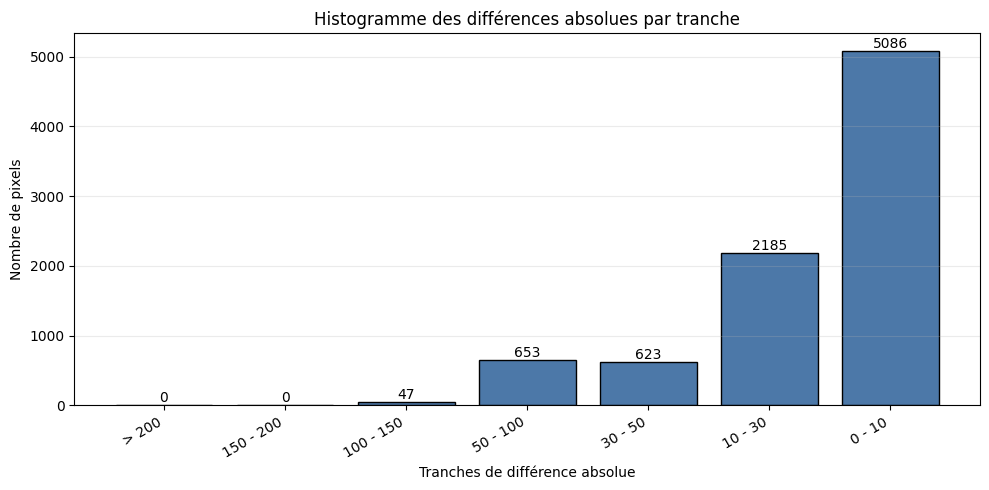

In [28]:
range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

range_counts = [
    num_gt_200,
    num_150_200,
    num_100_150,
    num_50_100,
    num_30_50,
    num_10_30,
    num_0_10,
]

plt.figure(figsize=(10, 5))
bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
plt.title("Histogramme des différences absolues par tranche")
plt.xlabel("Tranches de différence absolue")
plt.ylabel("Nombre de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, count in zip(bars, range_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(count),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


### Squared photometric error map

Cette figure n ajoute pas une nouvelle metrique.
Elle sert seulement a voir **ou** l erreur photometrique se concentre dans l image.


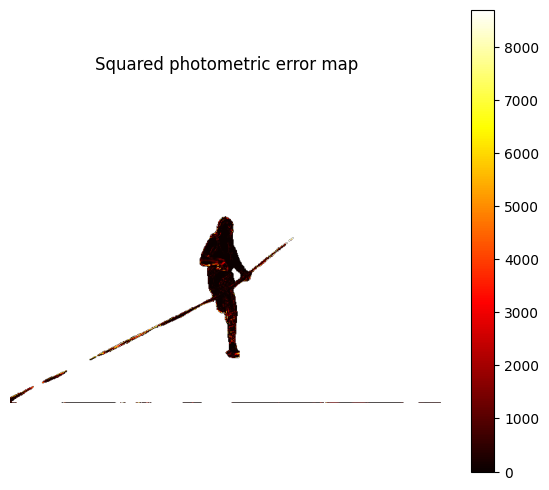

In [29]:
squared_error_map = evaluation["squared_error_map"]
valid_mask = evaluation["valid_mask"]

valid_values = squared_error_map[valid_mask]
vmax_sq = float(np.nanpercentile(valid_values, 99)) if valid_values.size > 0 else 1.0

plt.figure(figsize=(7, 6))
plt.imshow(squared_error_map, cmap="hot", vmin=0, vmax=vmax_sq)
plt.title("Squared photometric error map")
plt.axis("off")
plt.colorbar()
plt.show()


In [30]:
print("Only evaluation metric used in this notebook:")
print("  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels")


Only evaluation metric used in this notebook:
  photometric_error = sum((I_keyframe - I_reprojected)^2) over valid pixels


------
### **Scale sur toutes les images**

In [31]:
print(fake_frame_paths[0])

C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\dataset\real\real0_frames_first30\frame_00000.png


Sequence real0_first30:
  source size = 3840 x 2160
  working size level-0 = 640 x 480
  fx level-0 = 230.39999836425574
  fy level-0 = 307.19999781900765



[real0_first30] frame 0 -> keyframe de reference: frame_00000.png


xFormers not available


xFormers not available


Depth Anything loaded on cpu (97.47M parameters)


lvl:  4  initial error:  259.7027027027024
 error improvement too small, level converged! it:  5  error:  211.19905588966483  lambda:  14073748835532.8
lvl:  3  initial error:  1222.4776788473305


 error improvement too small, level converged! it:  12  error:  676.162265433373  lambda:  25.6
lvl:  2  initial error:  852.0399152519768


 error improvement too small, level converged! it:  11  error:  580.1333783788585  lambda:  1.6


[real0_first30] frame 1 -> frame_00001.png | sum error = 5815092.50 | mean abs error = 15.3514 | valid pixels = 8594


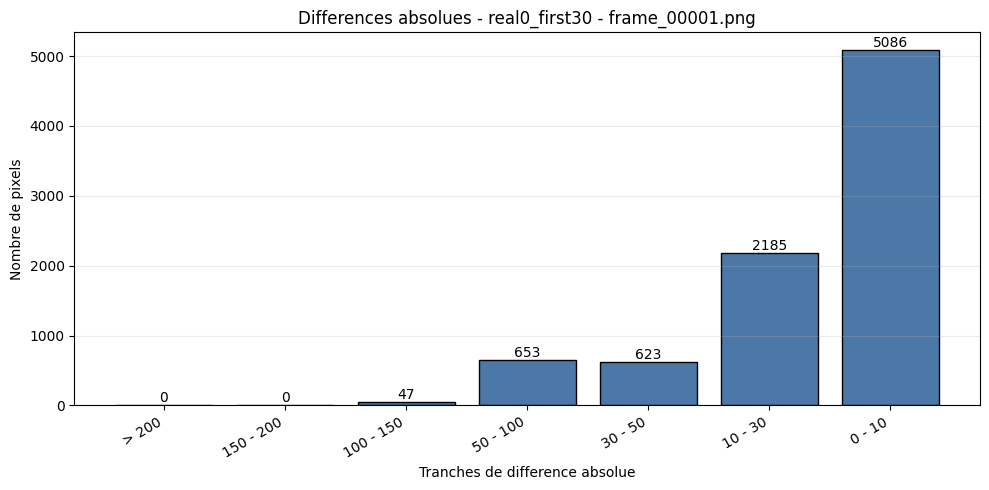

lvl:  4  initial error:  236.48648648648654
update too small, level converged! it:  1  error:  236.48648648648654  lambda:  1801439850948198.5
lvl:  3  initial error:  877.1363652322281


 error improvement too small, level converged! it:  8  error:  665.4616505512303  lambda:  102.4
lvl:  2  initial error:  758.5900266443409


 error improvement too small, level converged! it:  6  error:  631.0452153491159  lambda:  1.6


[real0_first30] frame 2 -> frame_00002.png | sum error = 5830490.50 | mean abs error = 16.1089 | valid pixels = 8587


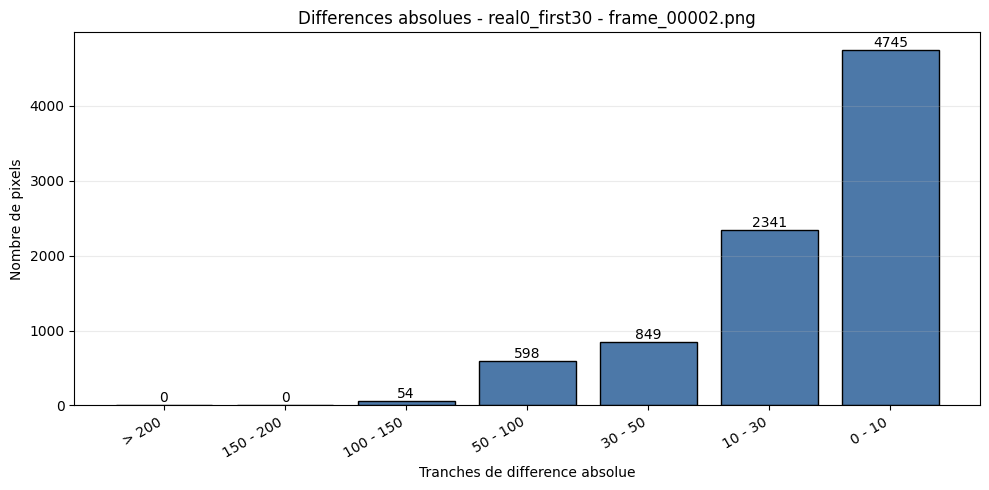

lvl:  4  initial error:  298.56756756756755
 error improvement too small, level converged! it:  5  error:  244.92133842357856  lambda:  51.2
lvl:  3  initial error:  1212.5897592713143


 error improvement too small, level converged! it:  11  error:  1043.0532002245325  lambda:  6.4
lvl:  2  initial error:  800.5971174918964


 error improvement too small, level converged! it:  7  error:  724.1301890839101  lambda:  439804651110.4


[real0_first30] frame 3 -> frame_00003.png | sum error = 5749104.50 | mean abs error = 16.2592 | valid pixels = 8576


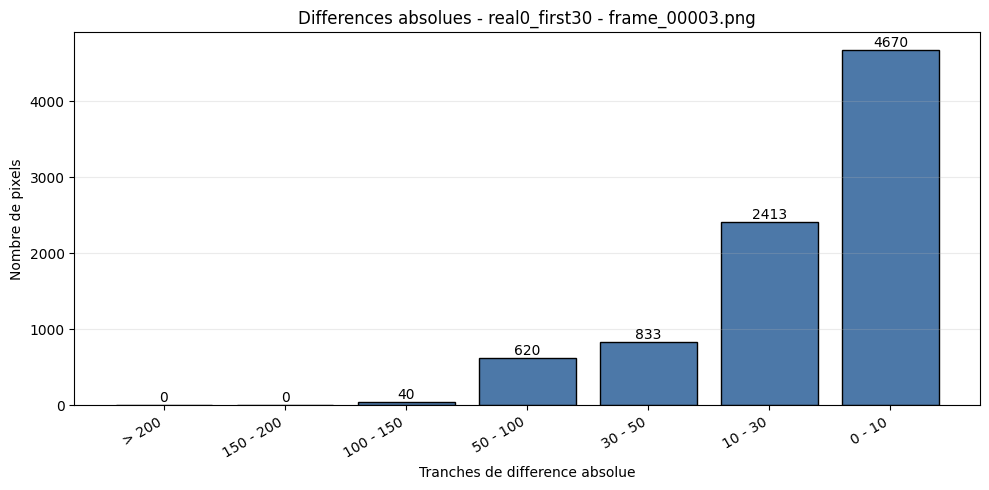

lvl:  4  initial error:  1383.0810810810776


update too small, level converged! it:  12  error:  388.24314022006564  lambda:  1801439850948198.5
lvl:  3  initial error:  1688.5665232222511


update too small, level converged! it:  6  error:  1340.9948798675025  lambda:  3602879701896397.0
lvl:  2  initial error:  1113.1247465161077


 error improvement too small, level converged! it:  3  error:  1021.8866102503648  lambda:  0.0


[real0_first30] frame 4 -> frame_00004.png | sum error = 9760550.00 | mean abs error = 22.4640 | valid pixels = 8269


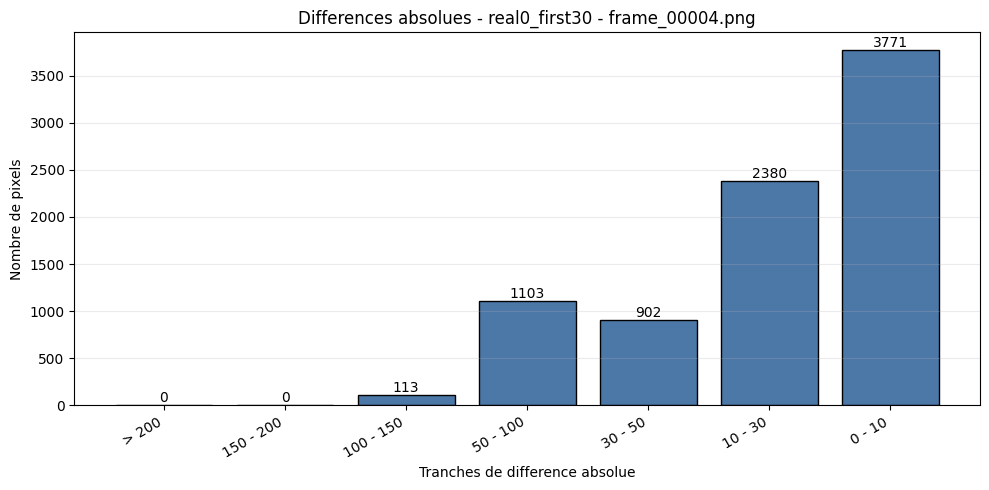

lvl:  4  initial error:  1735.9189189189133
 error improvement too small, level converged! it:  6  error:  278.90817004773595  lambda:  1.6
lvl:  3  initial error:  2003.2062208212396
 error improvement too small, level converged! it:  4  error:  1538.9211105482996  lambda:  3.2


lvl:  2  initial error:  1384.214560099847


 error improvement too small, level converged! it:  6  error:  1053.9897615994864  lambda:  25.6


[real0_first30] frame 5 -> frame_00005.png | sum error = 10045193.00 | mean abs error = 24.0098 | valid pixels = 7970


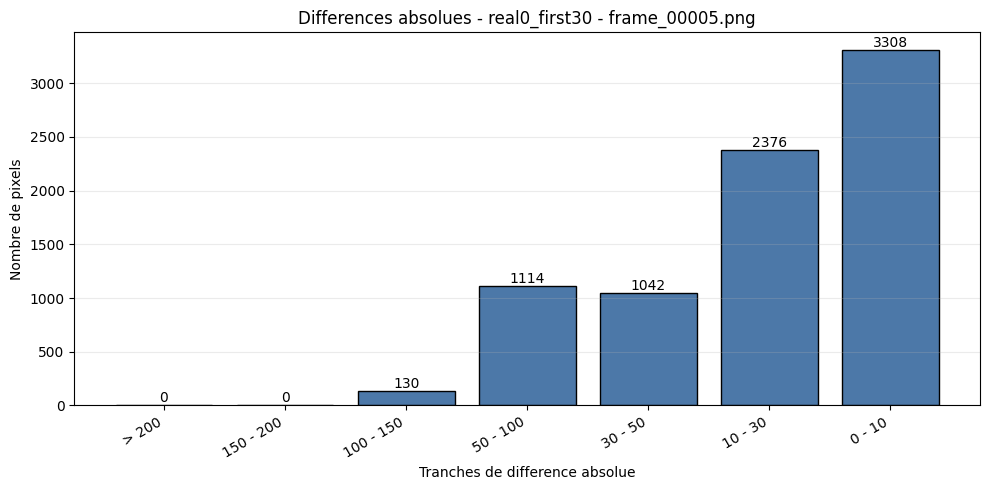

lvl:  4  initial error:  1605.8108108108056
 error improvement too small, level converged! it:  8  error:  346.56963776181215  lambda:  14073748835532.8
lvl:  3  initial error:  1747.4887524088174


 error improvement too small, level converged! it:  7  error:  1253.551885318675  lambda:  0.8
lvl:  2  initial error:  1458.7148903280993


 error improvement too small, level converged! it:  5  error:  1098.9106071546012  lambda:  7036874417766.4


[real0_first30] frame 6 -> frame_00006.png | sum error = 9292867.00 | mean abs error = 23.7074 | valid pixels = 7775


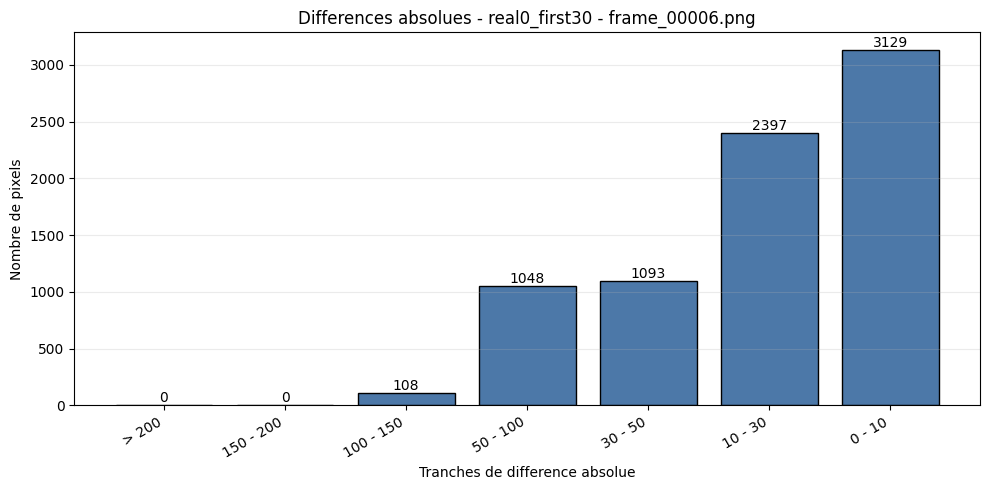

lvl:  4  initial error:  1418.7567567567517
 error improvement too small, level converged! it:  6  error:  421.43731642887195  lambda:  439804651110.4
lvl:  3  initial error:  1619.4594979261117


 error improvement too small, level converged! it:  8  error:  1359.4285150372762  lambda:  204.8
lvl:  2  initial error:  1664.794341030924


 error improvement too small, level converged! it:  8  error:  1229.2568828109727  lambda:  12.8


[real0_first30] frame 7 -> frame_00007.png | sum error = 10713430.00 | mean abs error = 26.1998 | valid pixels = 7699


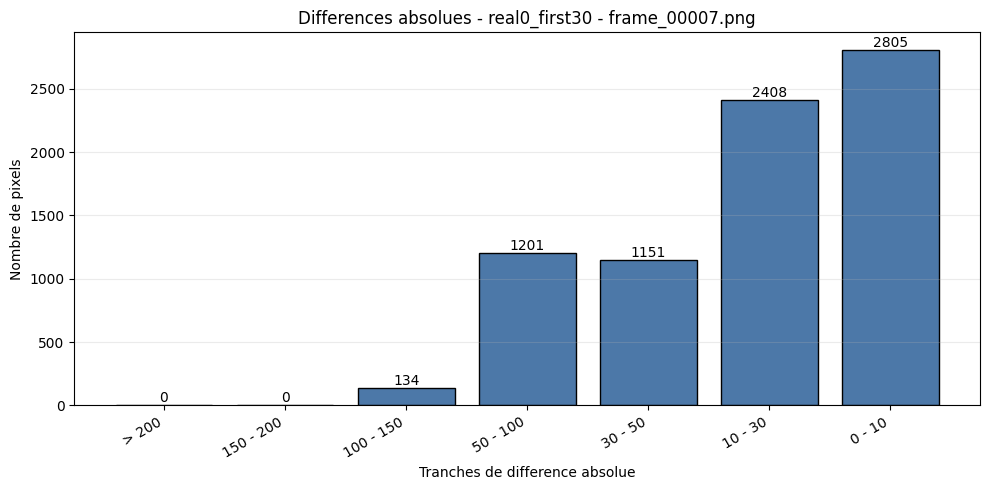

lvl:  4  initial error:  499.9459459459451
 error improvement too small, level converged! it:  9  error:  321.0392244986981  lambda:  12.8
lvl:  3  initial error:  1484.766810376635


 error improvement too small, level converged! it:  4  error:  1432.4741369157637  lambda:  14073748835532.8
lvl:  2  initial error:  1402.521960671499


 error improvement too small, level converged! it:  7  error:  1159.813138667553  lambda:  28147497671065.6


[real0_first30] frame 8 -> frame_00008.png | sum error = 10932084.00 | mean abs error = 24.2086 | valid pixels = 8559


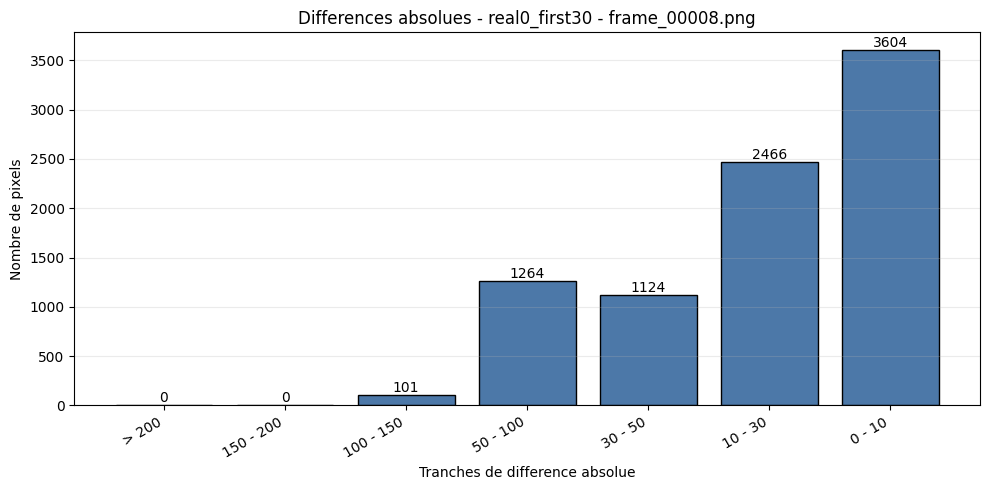

lvl:  4  initial error:  439.3783783783777
 error improvement too small, level converged! it:  6  error:  312.9937726920431  lambda:  6.4
lvl:  3  initial error:  1486.0952733166214
 error improvement too small, level converged! it:  1  error:  1485.8060524606983  lambda:  0.2
lvl:  2  initial error:  1337.500915852229


 error improvement too small, level converged! it:  4  error:  1224.66938059845  lambda:  7036874417766.4


[real0_first30] frame 9 -> frame_00009.png | sum error = 11243572.00 | mean abs error = 24.5741 | valid pixels = 8552


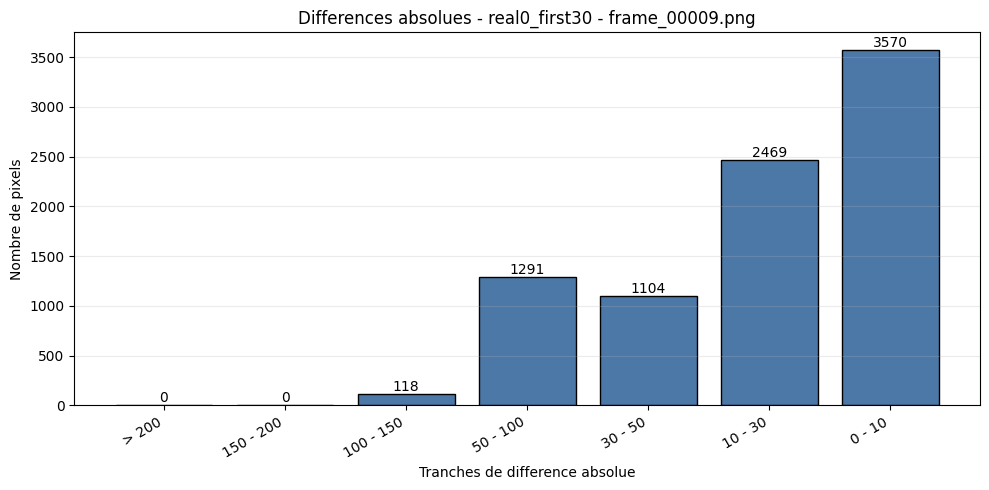

lvl:  4  initial error:  953.8108108108106
update too small, level converged! it:  2  error:  524.7119056356408  lambda:  3602879701896397.0
lvl:  3  initial error:  1840.3740504352827


 error improvement too small, level converged! it:  4  error:  1379.1677797688033  lambda:  1.6
lvl:  2  initial error:  1409.0723101204892


 error improvement too small, level converged! it:  7  error:  1204.858021201392  lambda:  0.1


[real0_first30] frame 10 -> frame_00010.png | sum error = 10857972.00 | mean abs error = 24.1236 | valid pixels = 8559


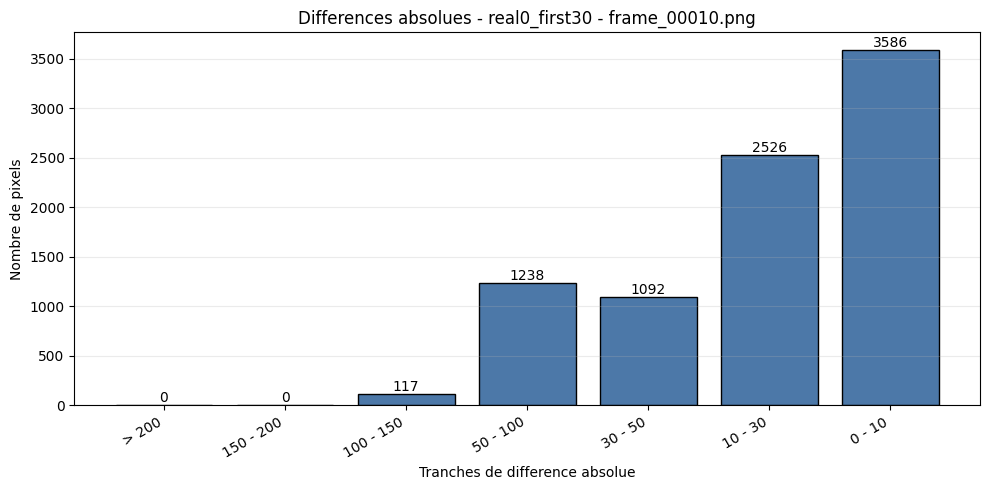

lvl:  4  initial error:  1063.432432432432
 error improvement too small, level converged! it:  3  error:  745.7642325418419  lambda:  51.2
lvl:  3  initial error:  1781.2630024630475
 error improvement too small, level converged! it:  2  error:  1751.4739582785332  lambda:  1.6
lvl:  2  initial error:  1597.4130697110434


 error improvement too small, level converged! it:  5  error:  1290.2978080928817  lambda:  0.2


[real0_first30] frame 11 -> frame_00011.png | sum error = 12442112.00 | mean abs error = 26.3893 | valid pixels = 8591


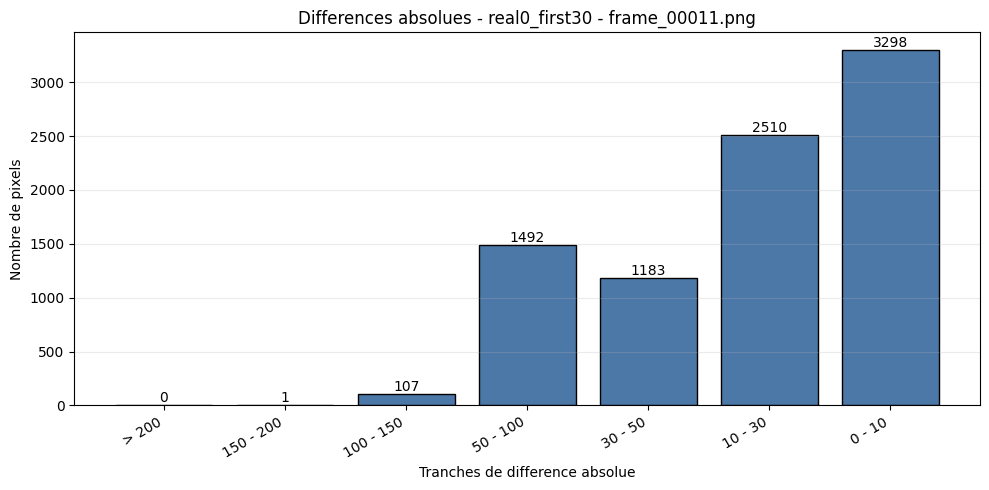

lvl:  4  initial error:  1282.6486486486483
 error improvement too small, level converged! it:  4  error:  823.5903637255096  lambda:  3.2
lvl:  3  initial error:  2044.5561019099698


 error improvement too small, level converged! it:  4  error:  1547.382438374768  lambda:  225179981368524.8
lvl:  2  initial error:  1368.651658746714


 error improvement too small, level converged! it:  4  error:  1275.4295605557122  lambda:  0.1


[real0_first30] frame 12 -> frame_00012.png | sum error = 11679397.00 | mean abs error = 25.5701 | valid pixels = 8584


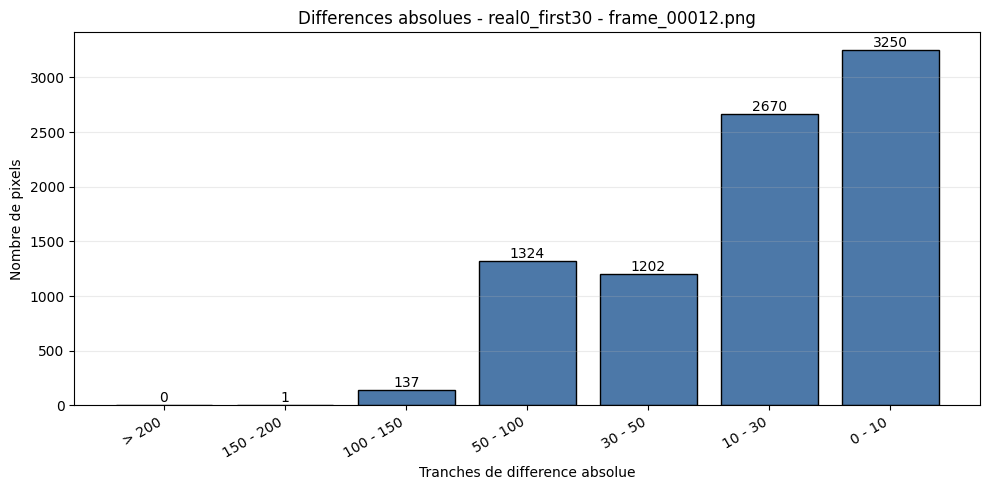

lvl:  4  initial error:  1413.9999999999982
 error improvement too small, level converged! it:  11  error:  763.7137171483206  lambda:  1.6
lvl:  3  initial error:  2173.4360198719714


 error improvement too small, level converged! it:  3  error:  1724.694552832342  lambda:  51.2
lvl:  2  initial error:  2010.7852590634595


 error improvement too small, level converged! it:  5  error:  1451.9746546202687  lambda:  409.6


[real0_first30] frame 13 -> frame_00013.png | sum error = 13360436.00 | mean abs error = 28.1580 | valid pixels = 8594


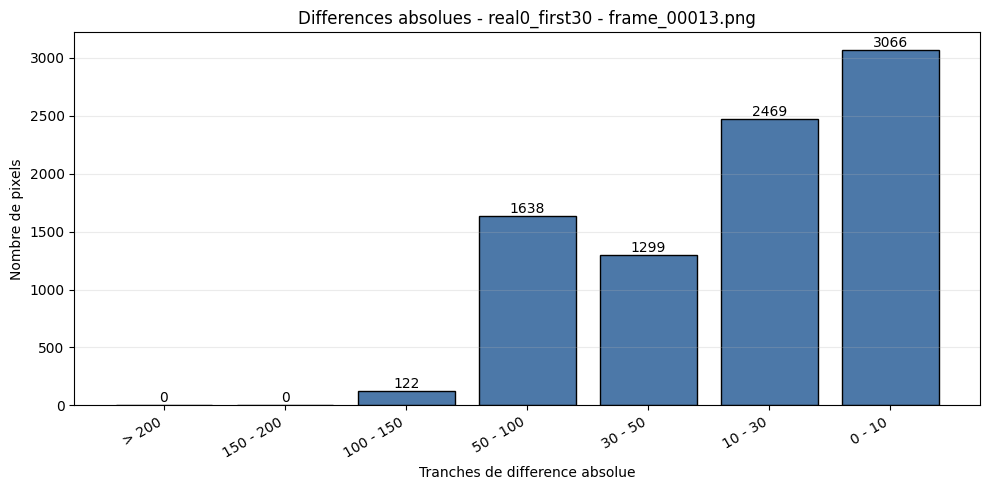

lvl:  4  initial error:  1730.3513513513506
 error improvement too small, level converged! it:  5  error:  1013.4385442465878  lambda:  225179981368524.8
lvl:  3  initial error:  2012.5968753340505


 error improvement too small, level converged! it:  5  error:  1666.3477236898098  lambda:  14073748835532.8
lvl:  2  initial error:  1690.0417971438253


 error improvement too small, level converged! it:  3  error:  1397.0099322187189  lambda:  0.1


[real0_first30] frame 14 -> frame_00014.png | sum error = 12681547.00 | mean abs error = 27.3299 | valid pixels = 8448


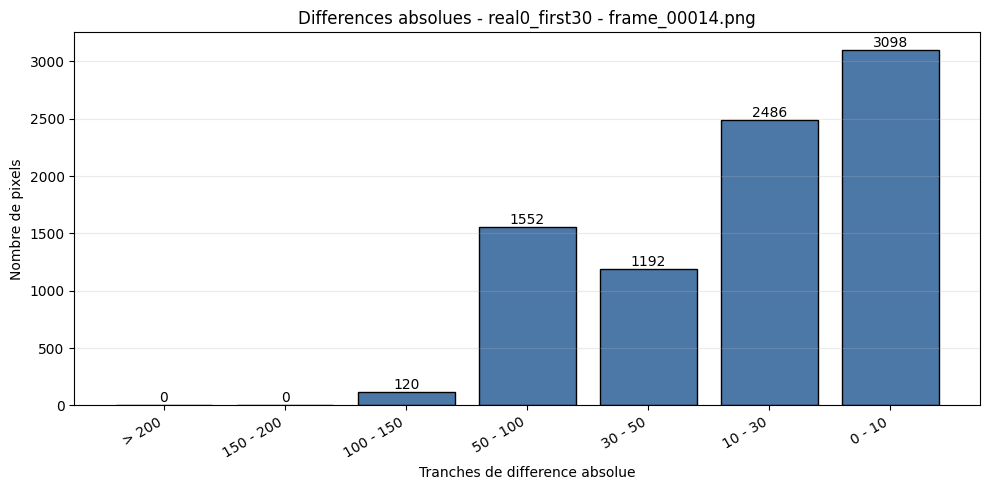

lvl:  4  initial error:  1794.162162162162
 error improvement too small, level converged! it:  4  error:  1132.7003236105127  lambda:  225179981368524.8
lvl:  3  initial error:  2298.8193136074187


 error improvement too small, level converged! it:  6  error:  1653.721540964741  lambda:  3518437208883.2
lvl:  2  initial error:  2203.0043947493596


 error improvement too small, level converged! it:  8  error:  1888.1360565689224  lambda:  0.2


[real0_first30] frame 15 -> frame_00015.png | sum error = 15440686.00 | mean abs error = 31.4556 | valid pixels = 8594


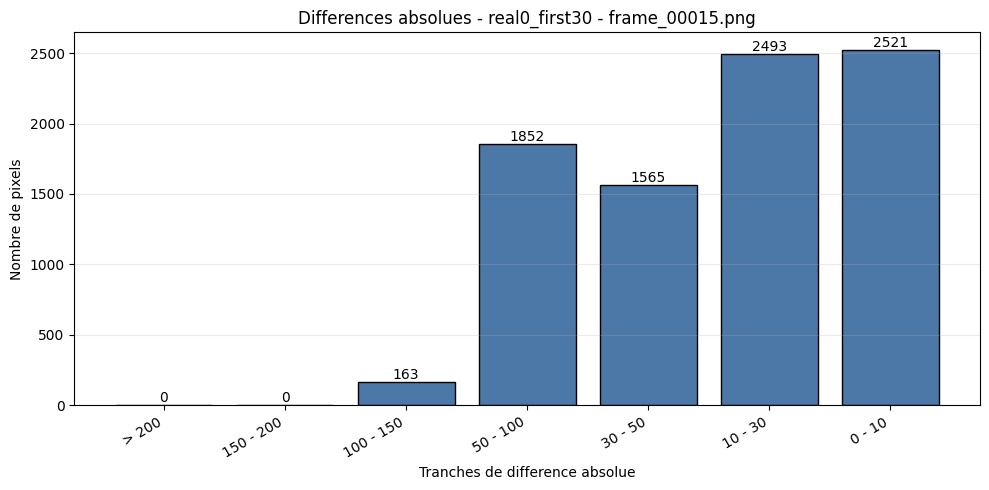

lvl:  4  initial error:  1762.108108108108


 error improvement too small, level converged! it:  14  error:  668.3885121295336  lambda:  112589990684262.4
lvl:  3  initial error:  1972.589110670801


 error improvement too small, level converged! it:  3  error:  1889.3919274993348  lambda:  56294995342131.2
lvl:  2  initial error:  1884.3910018628078


update too small, level converged! it:  7  error:  1735.3864208128434  lambda:  7205759403792794.0


[real0_first30] frame 16 -> frame_00016.png | sum error = 15373307.00 | mean abs error = 31.4025 | valid pixels = 8594


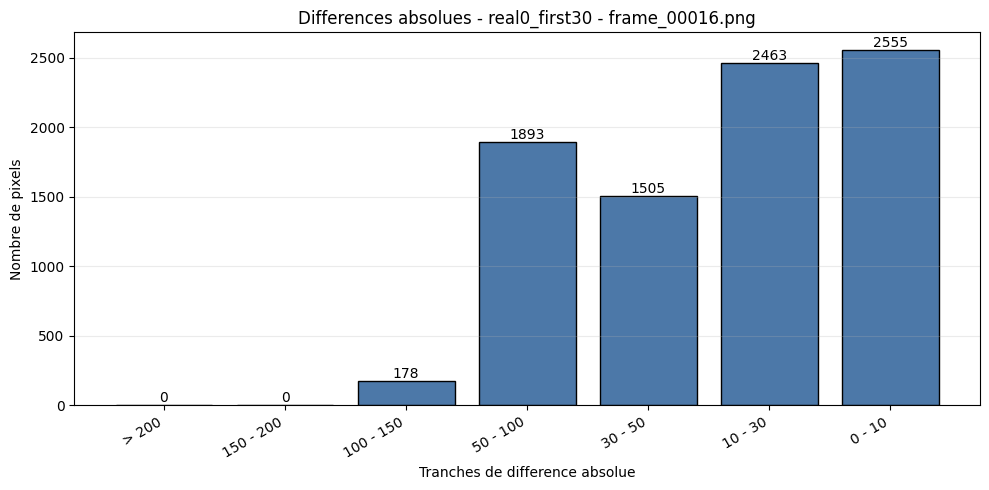

lvl:  4  initial error:  1449.2432432432433
 error improvement too small, level converged! it:  4  error:  836.1759505532708  lambda:  450359962737049.6
lvl:  3  initial error:  2260.109984351821


 error improvement too small, level converged! it:  3  error:  1752.4332074963877  lambda:  0.1
lvl:  2  initial error:  1936.8641270949888


 error improvement too small, level converged! it:  6  error:  1756.022399734128  lambda:  25.6


[real0_first30] frame 17 -> frame_00017.png | sum error = 15851641.00 | mean abs error = 32.4043 | valid pixels = 8594


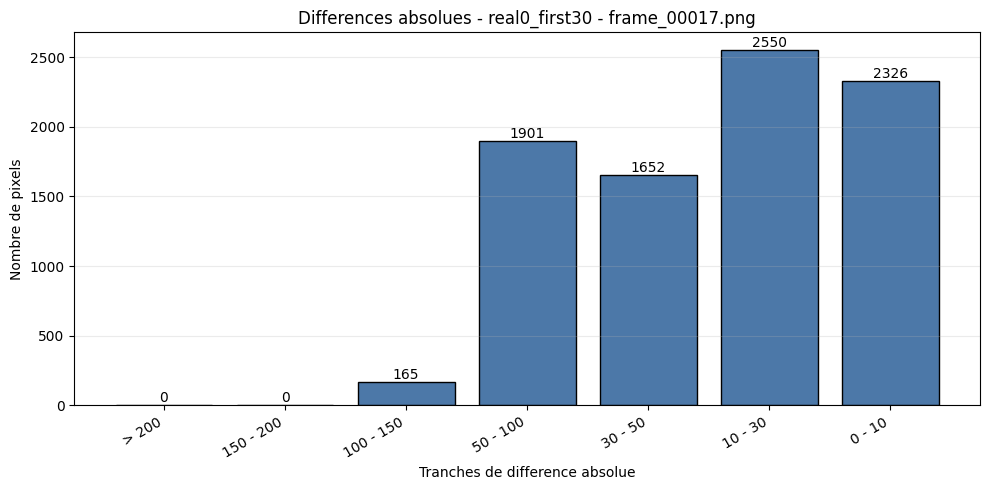

lvl:  4  initial error:  1770.3243243243244
 error improvement too small, level converged! it:  4  error:  964.4874242826215  lambda:  12.8
lvl:  3  initial error:  1999.9060545291043


 error improvement too small, level converged! it:  5  error:  1699.532609540788  lambda:  28147497671065.6
lvl:  2  initial error:  2622.478016472919


 error improvement too small, level converged! it:  12  error:  1623.117398604953  lambda:  0.1


[real0_first30] frame 18 -> frame_00018.png | sum error = 15729001.00 | mean abs error = 32.2921 | valid pixels = 8594


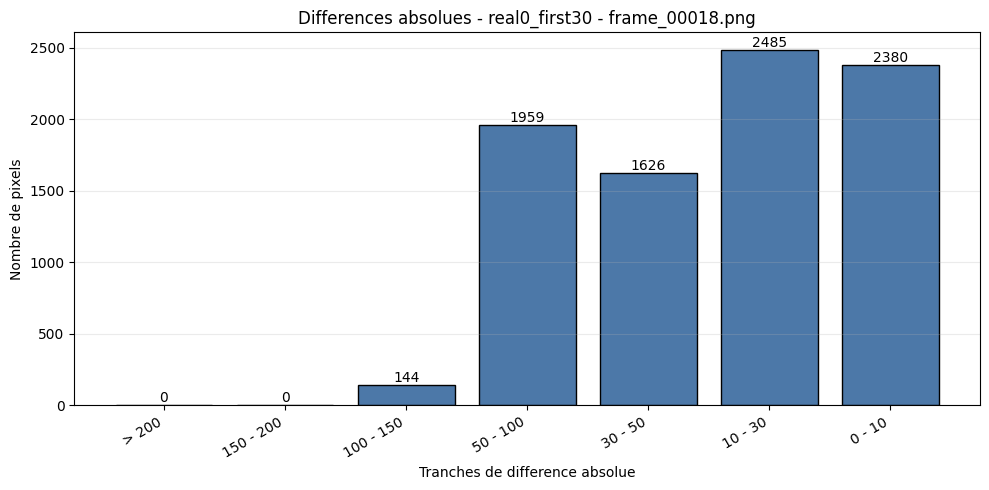

lvl:  4  initial error:  1990.7567567567567
 error improvement too small, level converged! it:  6  error:  805.943147993525  lambda:  7036874417766.4
lvl:  3  initial error:  2277.7008506059956


update too small, level converged! it:  11  error:  1686.9956443537242  lambda:  7205759403792794.0
lvl:  2  initial error:  1737.5202559788916


 error improvement too small, level converged! it:  1  error:  1735.9550179851572  lambda:  1.6


[real0_first30] frame 19 -> frame_00019.png | sum error = 15342519.00 | mean abs error = 30.7507 | valid pixels = 8594


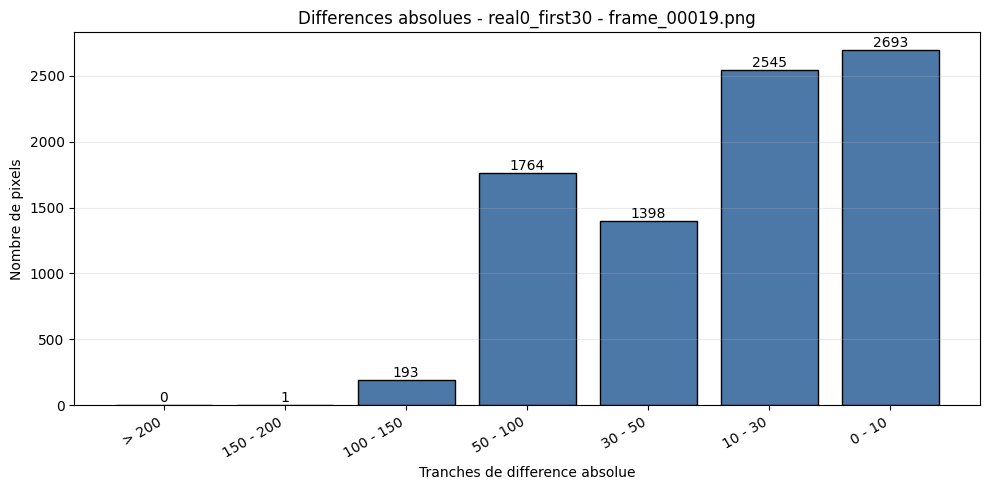

lvl:  4  initial error:  2378.135135135135


 error improvement too small, level converged! it:  8  error:  535.7854548594158  lambda:  225179981368524.8
lvl:  3  initial error:  2101.2499105151105


update too small, level converged! it:  10  error:  1625.8888020750505  lambda:  1.4411518807585588e+16
lvl:  2  initial error:  1715.5880831182335


update too small, level converged! it:  9  error:  1586.772896906039  lambda:  3602879701896397.0


[real0_first30] frame 20 -> frame_00020.png | sum error = 14426146.00 | mean abs error = 29.6219 | valid pixels = 8578


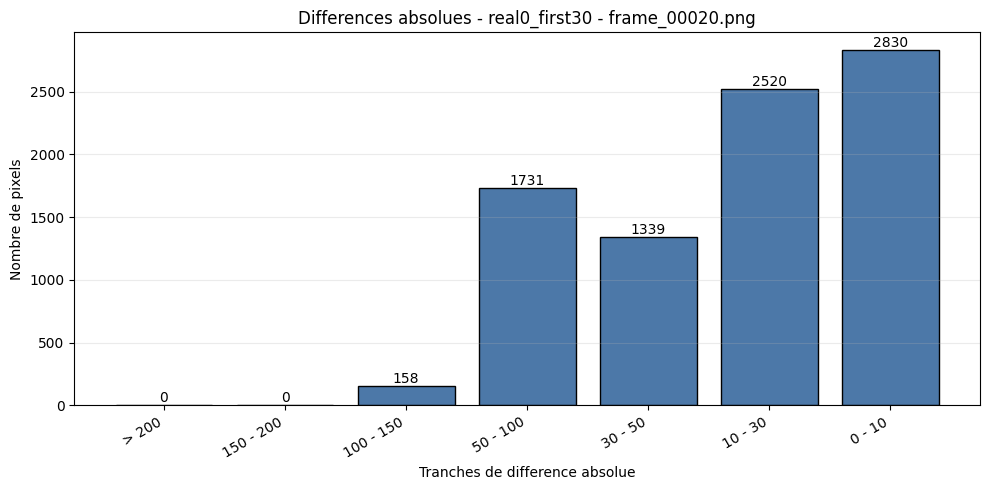

lvl:  4  initial error:  1888.837837837838
 error improvement too small, level converged! it:  4  error:  728.3507818104935  lambda:  12.8
lvl:  3  initial error:  1753.9248111632803


 error improvement too small, level converged! it:  5  error:  1602.9463698993588  lambda:  56294995342131.2
lvl:  2  initial error:  1750.313562571977


 error improvement too small, level converged! it:  2  error:  1684.2260417565228  lambda:  3.2


[real0_first30] frame 21 -> frame_00021.png | sum error = 15497083.00 | mean abs error = 31.2102 | valid pixels = 8594


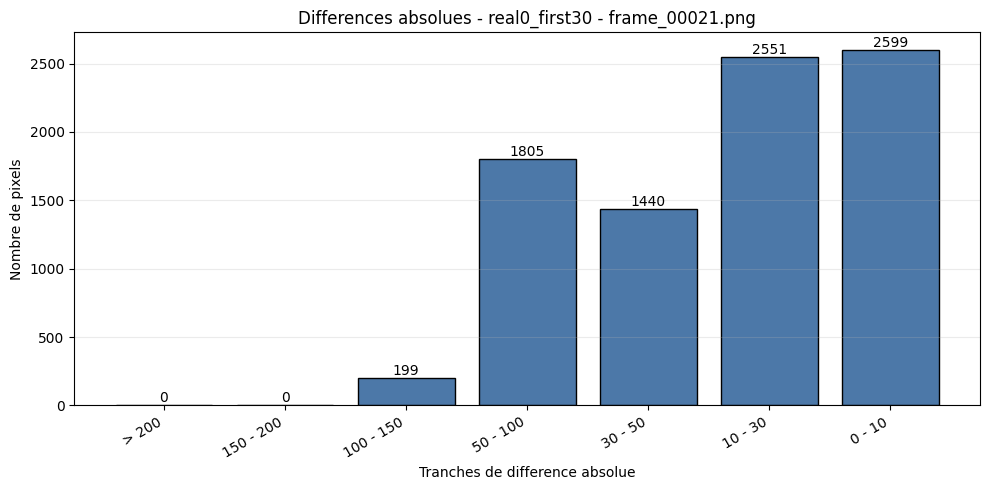

lvl:  4  initial error:  1581.5675675675675
 error improvement too small, level converged! it:  6  error:  635.0434413574989  lambda:  14073748835532.8
lvl:  3  initial error:  1871.054990094564


 error improvement too small, level converged! it:  5  error:  1639.266454439113  lambda:  0.1
lvl:  2  initial error:  1764.0673640649118


 error improvement too small, level converged! it:  10  error:  1575.5058321633094  lambda:  0.0


[real0_first30] frame 22 -> frame_00022.png | sum error = 14064288.00 | mean abs error = 29.1607 | valid pixels = 8571


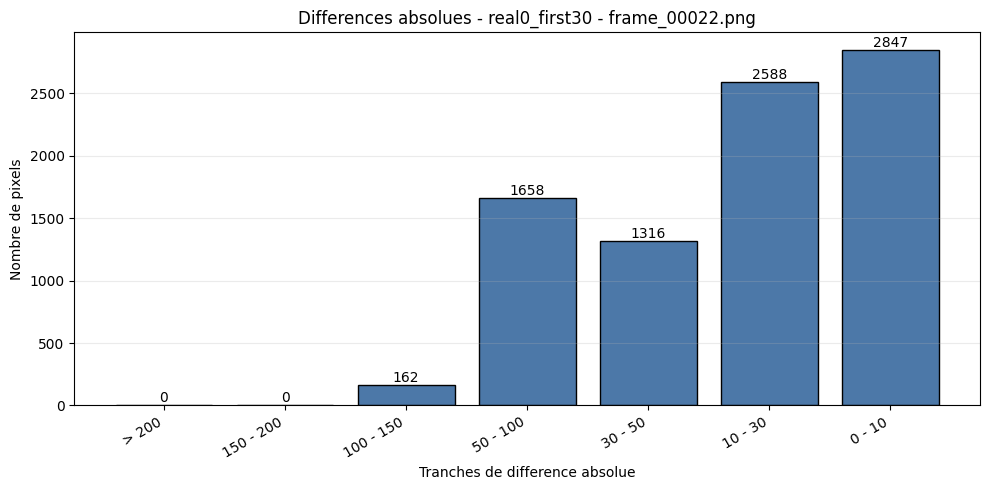

lvl:  4  initial error:  2013.4864864864865
 error improvement too small, level converged! it:  8  error:  560.8224739216063  lambda:  28147497671065.6
lvl:  3  initial error:  1938.3380910598546


update too small, level converged! it:  4  error:  1618.0935693545298  lambda:  900719925474099.2
lvl:  2  initial error:  1533.2709482509981


 error improvement too small, level converged! it:  3  error:  1474.784131248889  lambda:  0.4


[real0_first30] frame 23 -> frame_00023.png | sum error = 13757770.00 | mean abs error = 28.2662 | valid pixels = 8594


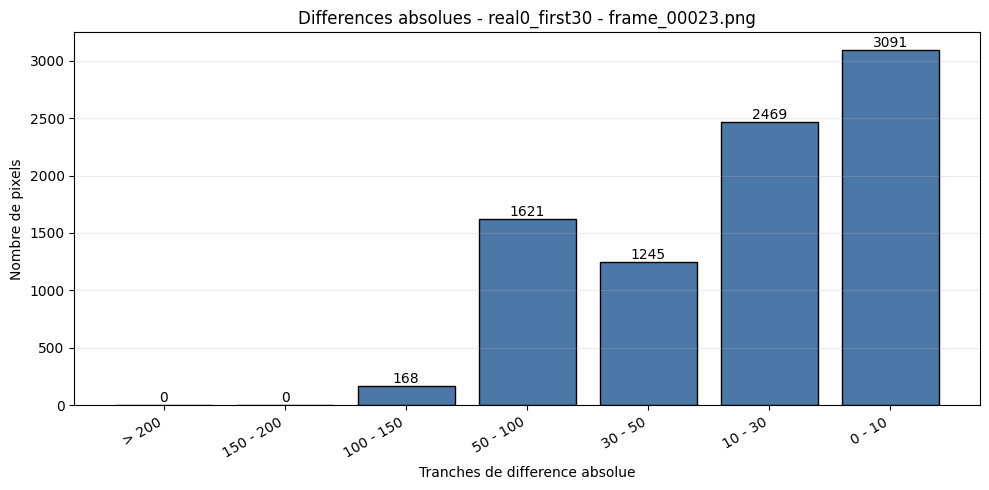

lvl:  4  initial error:  2150.405405405405
 error improvement too small, level converged! it:  10  error:  901.1883421200445  lambda:  112589990684262.4
lvl:  3  initial error:  2167.795922893664


 error improvement too small, level converged! it:  6  error:  1462.6410716114635  lambda:  56294995342131.2
lvl:  2  initial error:  1815.4762422356669


 error improvement too small, level converged! it:  7  error:  1653.1904060163758  lambda:  28147497671065.6


[real0_first30] frame 24 -> frame_00024.png | sum error = 14783967.00 | mean abs error = 30.0861 | valid pixels = 8594


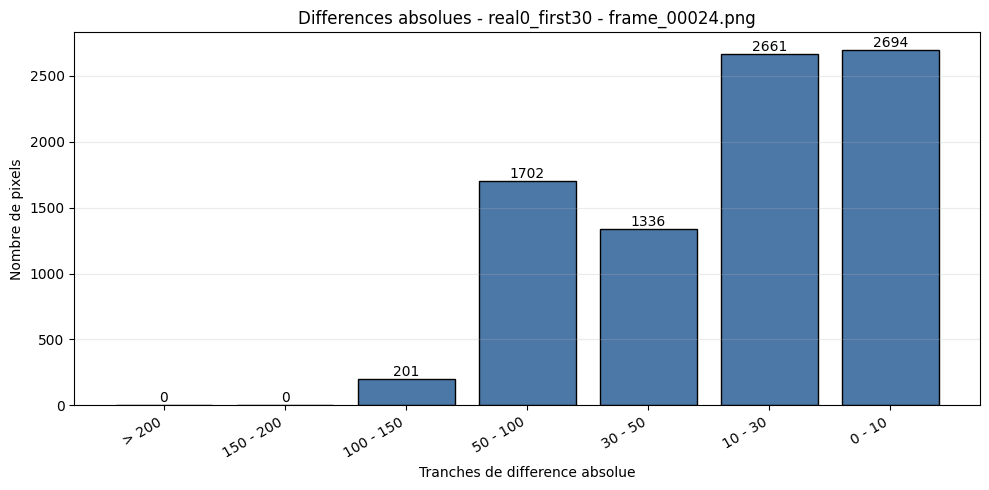

lvl:  4  initial error:  2276.972972972972
 error improvement too small, level converged! it:  7  error:  837.7340347337692  lambda:  112589990684262.4
lvl:  3  initial error:  2442.138105148183


 error improvement too small, level converged! it:  4  error:  1871.240129173522  lambda:  0.2
lvl:  2  initial error:  1837.983929507425


 error improvement too small, level converged! it:  5  error:  1667.1883455117384  lambda:  112589990684262.4


[real0_first30] frame 25 -> frame_00025.png | sum error = 15300013.00 | mean abs error = 30.9346 | valid pixels = 8594


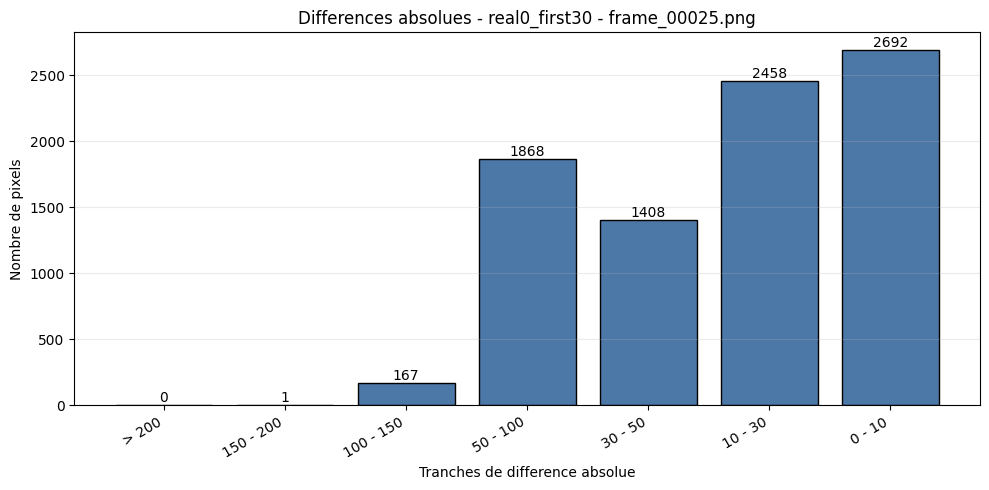

lvl:  4  initial error:  2109.8378378378375
 error improvement too small, level converged! it:  10  error:  875.3407603507677  lambda:  25.6
lvl:  3  initial error:  2243.8790950479456


 error improvement too small, level converged! it:  7  error:  1707.2430876297954  lambda:  450359962737049.6
lvl:  2  initial error:  2296.3438872226343


 error improvement too small, level converged! it:  3  error:  1867.6142181600128  lambda:  3.2


[real0_first30] frame 26 -> frame_00026.png | sum error = 13216854.00 | mean abs error = 33.3857 | valid pixels = 6800


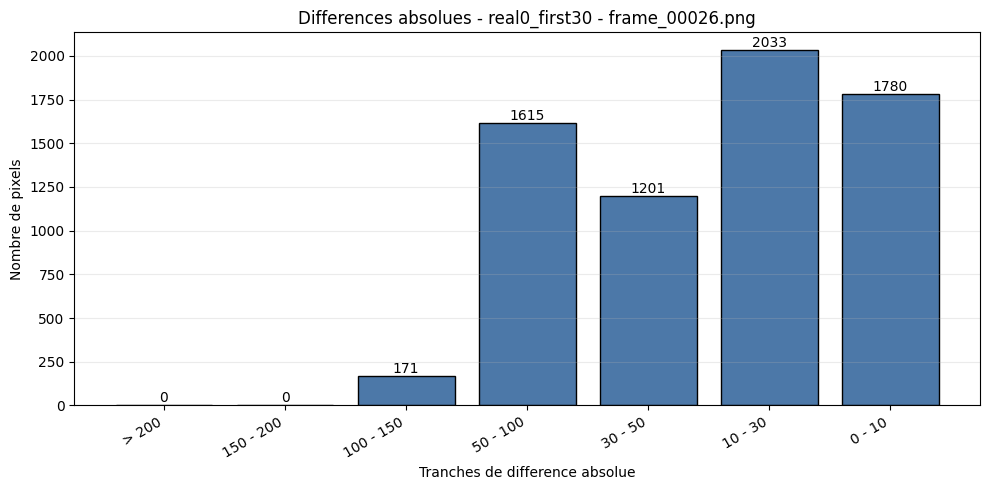

lvl:  4  initial error:  2326.4054054054054
 error improvement too small, level converged! it:  3  error:  1255.574056777783  lambda:  0.4
lvl:  3  initial error:  2384.006483752675
 error improvement too small, level converged! it:  2  error:  2275.1680338354345  lambda:  1.6
lvl:  2  initial error:  2720.1129613340877


 error improvement too small, level converged! it:  5  error:  2423.726614734375  lambda:  0.0


[real0_first30] frame 27 -> frame_00027.png | sum error = 21482074.00 | mean abs error = 38.3711 | valid pixels = 8594


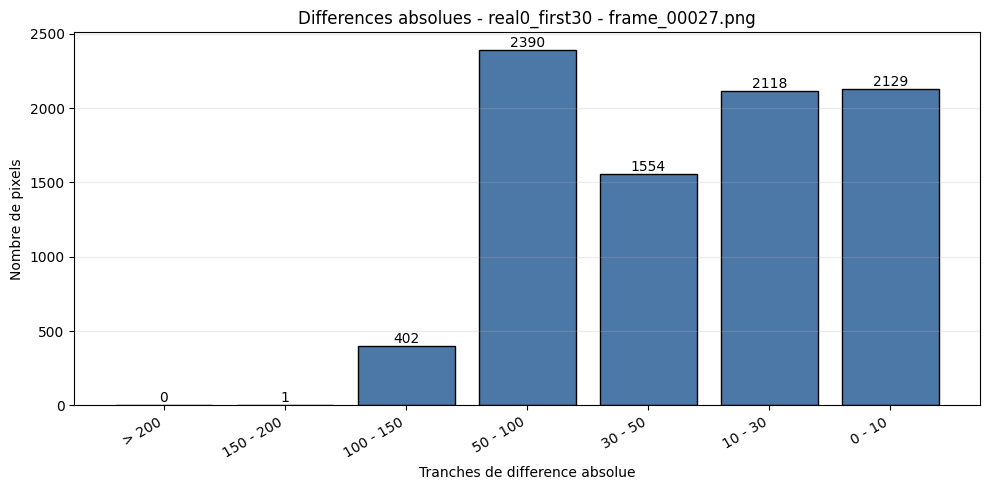

lvl:  4  initial error:  2557.729729729729
 error improvement too small, level converged! it:  5  error:  1325.847484388293  lambda:  6.4
lvl:  3  initial error:  3439.3261620887224


 error improvement too small, level converged! it:  4  error:  3217.2536218444843  lambda:  51.2
lvl:  2  initial error:  3564.020534749371


 error improvement too small, level converged! it:  5  error:  3497.758752847713  lambda:  0.2


[real0_first30] frame 28 -> frame_00028.png | sum error = 30325878.00 | mean abs error = 46.3901 | valid pixels = 8594


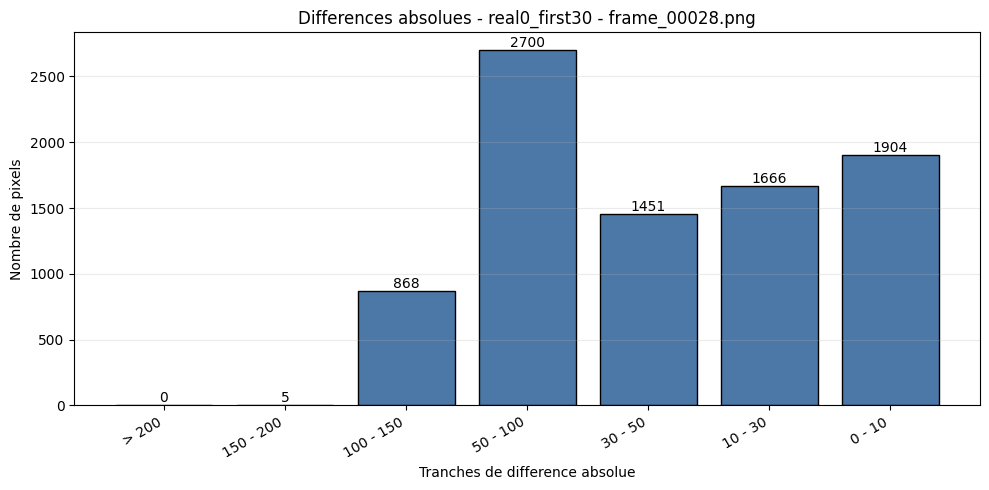

lvl:  4  initial error:  2964.054054054054
update too small, level converged! it:  6  error:  164.56360533715812  lambda:  9.223372036854776e+17
lvl:  3  initial error:  3105.125857882503


 error improvement too small, level converged! it:  2  error:  2873.4347458239154  lambda:  12.8
lvl:  2  initial error:  2747.1883596030193


 error improvement too small, level converged! it:  1  error:  2747.1498355781237  lambda:  819.2


[real0_first30] frame 29 -> frame_00029.png | sum error = 18142788.00 | mean abs error = 38.8428 | valid pixels = 6779


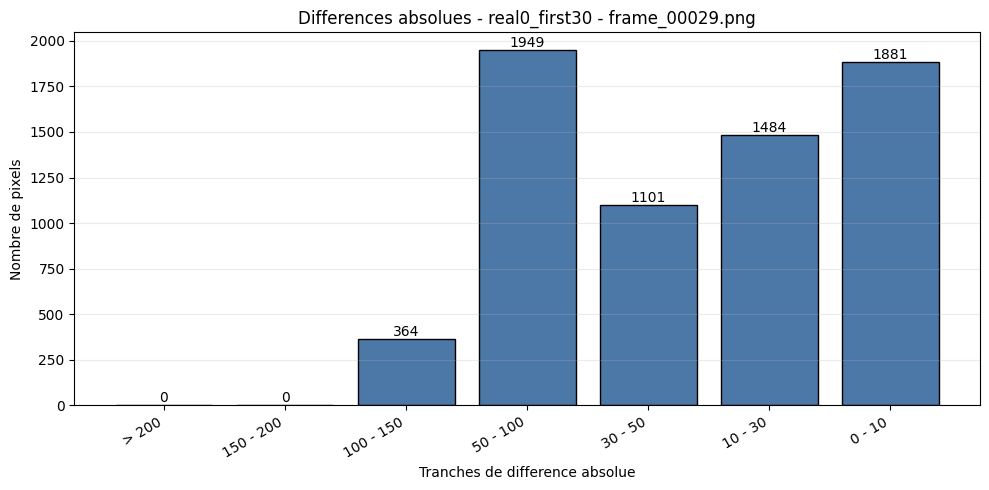

In [32]:
# Boucle simple sur toute la sequence: depth estimation puis pose estimation par frame.
# Cette version reconstruit une camera coherente pour la sequence traitee
# et reinitialise le solveur pour eviter de reutiliser un etat precedent.
frame_paths = fake_frame_paths[:30]

if len(frame_paths) < 2:
    raise ValueError("Il faut au moins 2 frames pour lancer le pipeline.")

sequence_name = "real0_first30"
sequence_keyframe = None
sequence_results = []

first_image_path = normalize_image_path(frame_paths[0])
first_image = load_gray_image(first_image_path)
sequence_height, sequence_width = first_image.shape[:2]

sequence_cam = camera.camera(
    USER_FX,
    USER_FY,
    USER_CX,
    USER_CY,
    sequence_width,
    sequence_height,
)
sequence_pose_solver = pose_estimator_gauss_newton.pose_estimator_gauss_newton(sequence_cam, show_debug=False)

print(f"Sequence {sequence_name}:")
print(f"  source size = {sequence_width} x {sequence_height}")
print(f"  working size level-0 = {sequence_cam.width[0]} x {sequence_cam.height[0]}")
print(f"  fx level-0 = {sequence_cam.fx[0]}")
print(f"  fy level-0 = {sequence_cam.fy[0]}")
print()

for step, image_path in enumerate(frame_paths):
    image_path = normalize_image_path(image_path)
    image = load_gray_image(image_path)

    if image.shape[:2] != (sequence_height, sequence_width):
        raise ValueError(
            f"Toutes les images de la sequence {sequence_name} doivent avoir la meme taille. "
            f"Attendu: {(sequence_height, sequence_width)}, obtenu: {image.shape[:2]} pour {image_path.name}"
        )

    depth_map = load_depth_map(image_path)
    inv_depth, inv_depth_var, depth_valid_mask = depth_to_invdepth(depth_map)

    current_frame = frameData.frameData()
    current_frame.setImage(image)
    current_frame.setInvDepth(inv_depth, inv_depth_var)

    if step == 0:
        sequence_keyframe = current_frame
        print(f"[{sequence_name}] frame {step} -> keyframe de reference: {image_path.name}")
        sequence_results.append(
            {
                "index": step,
                "image_path": str(image_path),
                "depth_valid_ratio": float(depth_valid_mask.mean()),
                "pose_matrix": current_frame.pose.as_matrix(),
                "photometric_error": None,
                "photometric_error_mean": None,
                "valid_pixel_count": None,
                "histogram_counts": None,
            }
        )
        continue

    sequence_pose_solver.optPose(current_frame, sequence_keyframe)
    evaluation = compute_photometric_error(current_frame, sequence_keyframe, sequence_cam, lvl=0)

    abs_error_map = np.sqrt(evaluation["squared_error_map"])
    valid_mask = evaluation["valid_mask"]
    valid_abs_errors = abs_error_map[valid_mask]
    valid_pixel_count = int(valid_abs_errors.size)
    photometric_error = float(evaluation["photometric_error"])
    photometric_error_mean = float(valid_abs_errors.mean()) if valid_pixel_count > 0 else None
    mean_error_display = f"{photometric_error_mean:.4f}" if photometric_error_mean is not None else "None"

    print(
        f"[{sequence_name}] frame {step} -> {image_path.name} | "
        f"sum error = {photometric_error:.2f} | "
        f"mean abs error = {mean_error_display} | "
        f"valid pixels = {valid_pixel_count}"
    )

    num_gt_200 = int(np.sum(valid_abs_errors > 200))
    num_150_200 = int(np.sum((valid_abs_errors >= 150) & (valid_abs_errors <= 200)))
    num_100_150 = int(np.sum((valid_abs_errors >= 100) & (valid_abs_errors < 150)))
    num_50_100 = int(np.sum((valid_abs_errors >= 50) & (valid_abs_errors < 100)))
    num_30_50 = int(np.sum((valid_abs_errors >= 30) & (valid_abs_errors < 50)))
    num_10_30 = int(np.sum((valid_abs_errors >= 10) & (valid_abs_errors < 30)))
    num_0_10 = int(np.sum((valid_abs_errors >= 0) & (valid_abs_errors < 10)))

    range_labels = [
        "> 200",
        "150 - 200",
        "100 - 150",
        "50 - 100",
        "30 - 50",
        "10 - 30",
        "0 - 10",
    ]

    range_counts = [
        num_gt_200,
        num_150_200,
        num_100_150,
        num_50_100,
        num_30_50,
        num_10_30,
        num_0_10,
    ]

    plt.figure(figsize=(10, 5))
    bars = plt.bar(range_labels, range_counts, color="#4C78A8", edgecolor="black")
    plt.title(f"Differences absolues - {sequence_name} - {image_path.name}")
    plt.xlabel("Tranches de difference absolue")
    plt.ylabel("Nombre de pixels")
    plt.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=30, ha="right")

    for bar, count in zip(bars, range_counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(count),
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    sequence_results.append(
        {
            "index": step,
            "image_path": str(image_path),
            "depth_valid_ratio": float(depth_valid_mask.mean()),
            "pose_matrix": current_frame.pose.as_matrix(),
            "photometric_error": photometric_error,
            "photometric_error_mean": photometric_error_mean,
            "valid_pixel_count": valid_pixel_count,
            "histogram_counts": range_counts,
        }
    )


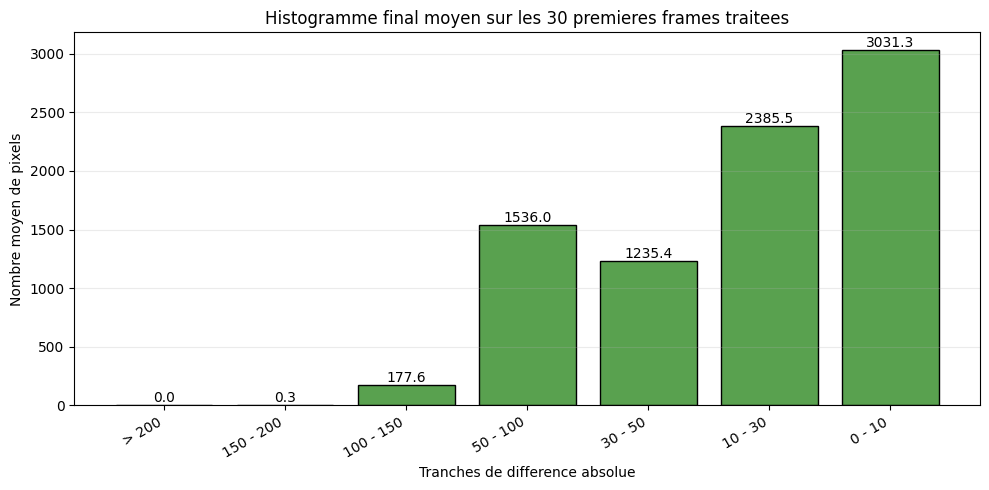

Histogramme final moyen:
     > 200 -> 0.00
  150 - 200 -> 0.34
  100 - 150 -> 177.62
  50 - 100 -> 1536.00
   30 - 50 -> 1235.38
   10 - 30 -> 2385.52
    0 - 10 -> 3031.31
Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\real0_first30_mean_histogram.png


In [33]:
valid_histogram_results = [
    item for item in sequence_results
    if item.get("histogram_counts") is not None
]

if not valid_histogram_results:
    raise ValueError("Aucun histogramme valide disponible pour calculer la moyenne finale.")

histogram_matrix = np.array([item["histogram_counts"] for item in valid_histogram_results], dtype=np.float64)
mean_histogram_counts = histogram_matrix.mean(axis=0)

final_range_labels = [
    "> 200",
    "150 - 200",
    "100 - 150",
    "50 - 100",
    "30 - 50",
    "10 - 30",
    "0 - 10",
]

plt.figure(figsize=(10, 5))
bars = plt.bar(final_range_labels, mean_histogram_counts, color="#59A14F", edgecolor="black")
plt.title("Histogramme final moyen sur les 30 premieres frames traitees")
plt.xlabel("Tranches de difference absolue")
plt.ylabel("Nombre moyen de pixels")
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=30, ha="right")

for bar, value in zip(bars, mean_histogram_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
final_histogram_path = IMAGE_OUTPUT_DIR / "real0_first30_mean_histogram.png"
plt.savefig(final_histogram_path, dpi=150, bbox_inches="tight")
plt.show()

print("Histogramme final moyen:")
for label, value in zip(final_range_labels, mean_histogram_counts):
    print(f"  {label:>8} -> {value:.2f}")
print(f"Image sauvegardee : {final_histogram_path}")


13418546.98275862


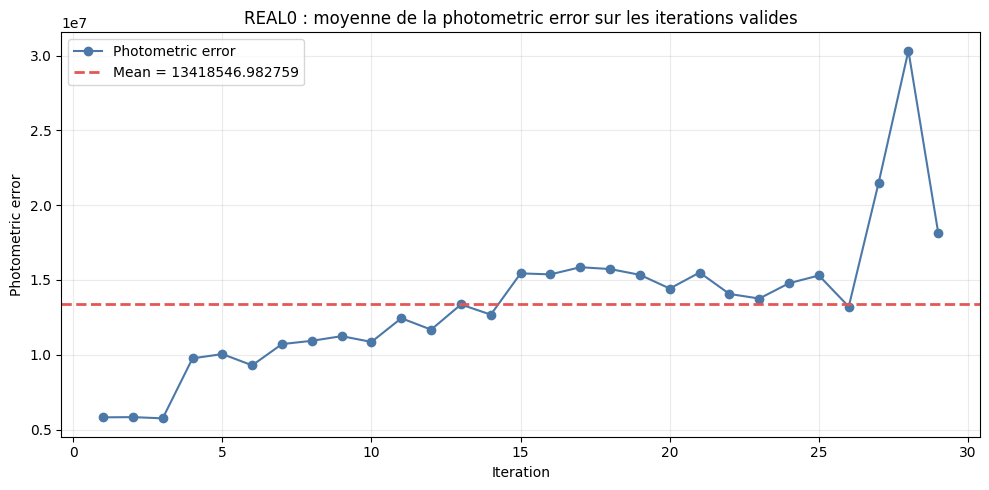

Image sauvegardee : C:\Users\conqu\Videos\Detection_Deep_Fake\Repo_1st_test\Implementation_1\image\real0_first30_photometric_error.png


In [34]:
valid_results = [
    item for item in sequence_results
    if item["photometric_error"] is not None
]

if not valid_results:
    raise ValueError("Aucun resultat valide disponible pour calculer la moyenne des erreurs photometriques.")

iteration_indices = [item["index"] for item in valid_results]
photometric_errors = [item["photometric_error"] for item in valid_results]
mean_photometric_error = float(np.mean(photometric_errors))

print(mean_photometric_error)

plt.figure(figsize=(10, 5))
plt.plot(iteration_indices, photometric_errors, marker="o", color="#4C78A8", label="Photometric error")
plt.axhline(
    mean_photometric_error,
    color="#E45756",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_photometric_error:.6f}"
)
plt.title("REAL0 : moyenne de la photometric error sur les iterations valides")
plt.xlabel("Iteration")
plt.ylabel("Photometric error")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
final_error_curve_path = IMAGE_OUTPUT_DIR / "real0_first30_photometric_error.png"
plt.savefig(final_error_curve_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Image sauvegardee : {final_error_curve_path}")
